# Merge Data

In [ ]:
import pandas as pd
import os

# List of match folder names
match_folders = ['match1', 'match2', 'match3', 'match4', 'match5']

# Initialize empty lists to store DataFrames from each folder
coordinates_list = []
passes_list = []

# Loop through each match folder and read the corresponding CSV files
for folder in match_folders:
    coordinates_path = os.path.join(folder, 'coordinates.csv')
    passes_path = os.path.join(folder, 'passes.csv')
    
    if os.path.exists(coordinates_path):
        df_coord = pd.read_csv(coordinates_path)
        df_coord['match'] = folder  # Add match identifier column
        coordinates_list.append(df_coord)

    if os.path.exists(passes_path):
        df_pass = pd.read_csv(passes_path)
        df_pass['match'] = folder  # Add match identifier column
        passes_list.append(df_pass)

# Concatenate all match DataFrames into a single DataFrame
all_coordinates = pd.concat(coordinates_list, ignore_index=True)
all_passes = pd.concat(passes_list, ignore_index=True)

# Write the merged DataFrames into an Excel file with two sheets
output_path = 'merged_matches.xlsx'
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    all_coordinates.to_excel(writer, sheet_name='coordinates', index=False)
    all_passes.to_excel(writer, sheet_name='passes', index=False)

print(f'Saved as {output_path}')


In [51]:
df_passes = pd.read_excel('merged_matches.xlsx', sheet_name='passes')
df_passes['timestamp'] = pd.to_datetime(df_passes['timestamp'], unit='ms')
df_coordinates = pd.read_excel('merged_matches.xlsx', sheet_name='coordinates', parse_dates=['timestamp'])


In [52]:
df_passes.head()

,Unnamed: 0,timestamp,ballId,ballposX,ballposY,Match_id,matchDuration,startTime,Type,passedPlayerId,...,Playing direction_second half_away,secondHalfBeginTime,Playing direction_first half_5325,Playing direction_first half_5328,Playing direction_second half_5325,Playing direction_second half_5328,Playing direction_first half_5039,Playing direction_first half_5038,Playing direction_second half_5039,Playing direction_second half_5038
0,0.0,2017-08-20 22:28:59.602,304B,26.57,12.94,0F65BAAB-3EF8-4F3D-A44A-E70204AD0046,0 days 01:21:49.801000,1503268107400,Pass,96844,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,2017-08-20 22:29:10.805,304B,17.99,32.73,0F65BAAB-3EF8-4F3D-A44A-E70204AD0046,0 days 01:21:49.801000,1503268107400,Pass,96846,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,2017-08-20 22:29:38.811,304B,36.21,39.36,0F65BAAB-3EF8-4F3D-A44A-E70204AD0046,0 days 01:21:49.801000,1503268107400,Pass,96841,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.0,2017-08-20 22:30:01.815,304B,89.32,19.20,0F65BAAB-3EF8-4F3D-A44A-E70204AD0046,0 days 01:21:49.801000,1503268107400,Pass,96871,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.0,2017-08-20 22:30:05.206,304B,78.37,25.69,0F65BAAB-3EF8-4F3D-A44A-E70204AD0046,0 days 01:21:49.801000,1503268107400,Pass,96873,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
df_coordinates.head()

,Unnamed: 0,timestamp,ballId,ballposX,ballposY,playerId0,posX0,posY0,playerId1,posX1,...,playerId37,posX37,posY37,playerId38,posX38,posY38,playerId39,posX39,posY39,match
0,0,2017-08-20 22:28:27.400,304B,-100.0,-100.0,96851,-100.0,-100.0,96844,28.484375,...,96880.0,55.93750,24.828125,96855.0,47.59375,43.12500,96845.0,32.062500,34.03125,match1
1,1,2017-08-20 22:28:27.601,304B,-100.0,-100.0,96851,-100.0,-100.0,96844,28.781250,...,96880.0,56.12500,24.968750,96855.0,49.12500,43.09375,96845.0,31.953125,34.09375,match1
2,2,2017-08-20 22:28:27.800,304B,-100.0,-100.0,96851,-100.0,-100.0,96844,28.937500,...,96880.0,55.75000,24.937500,96855.0,49.00000,43.00000,96845.0,31.890625,34.18750,match1
3,3,2017-08-20 22:28:28.147,304B,-100.0,-100.0,96851,-100.0,-100.0,96844,29.000000,...,96880.0,55.56250,25.015625,96855.0,50.00000,43.37500,96845.0,31.875000,34.28125,match1
4,4,2017-08-20 22:28:28.200,304B,-100.0,-100.0,96851,-100.0,-100.0,96844,29.000000,...,96880.0,54.84375,25.546875,96855.0,50.31250,43.43750,96845.0,31.921875,34.50000,match1


# Calculate Speed

In [56]:
import numpy as np

# Ensure the coordinates table is sorted by timestamp
df_coordinates = df_coordinates.sort_values('timestamp')

# Define a function to compute pass speed from coordinates
def compute_pass_speed_from_coordinates(pass_time):
    # Find the index of the current pass timestamp in the coordinates table
    i = df_coordinates['timestamp'].searchsorted(pass_time)
    
    # If the index is out of range, return NaN
    if i >= len(df_coordinates) - 1:
        return np.nan

    x1, y1 = df_coordinates.iloc[i]['ballposX'], df_coordinates.iloc[i]['ballposY']
    t1 = df_coordinates.iloc[i]['timestamp']
    
    x2, y2 = df_coordinates.iloc[i+4]['ballposX'], df_coordinates.iloc[i+1]['ballposY']  # mixed step
    t2 = df_coordinates.iloc[i+4]['timestamp']
    
    # Time difference
    dt = (t2 - t1).total_seconds()
    if dt == 0:
        return np.nan
    
    # Euclidean distance
    dist = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

    return dist / dt

# Apply the speed calculation to each pass event
df_passes['pass_speed'] = df_passes['timestamp'].apply(compute_pass_speed_from_coordinates)


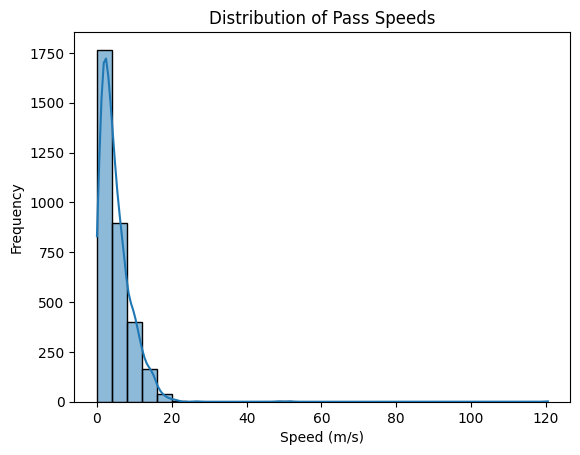

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_passes['pass_speed'].dropna(), bins=30, kde=True)
plt.title("Distribution of Pass Speeds")
plt.xlabel("Speed (m/s)")
plt.ylabel("Frequency")
plt.show()


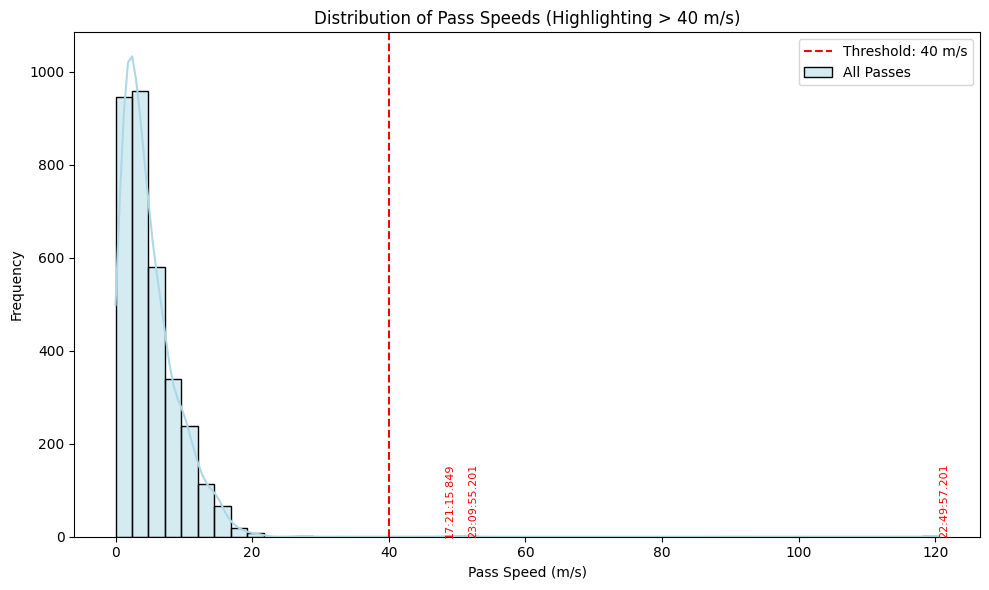

In [58]:
fast_passes = df_passes[df_passes['pass_speed'] > 40]

plt.figure(figsize=(10, 6))
sns.histplot(df_passes['pass_speed'], bins=50, kde=True, color='lightblue', label='All Passes')
plt.axvline(40, color='red', linestyle='--', label='Threshold: 40 m/s')

# Add anomalies to the graph
for i, row in fast_passes.iterrows():
    plt.text(row['pass_speed'], 0.5, row['timestamp'].strftime('%H:%M:%S.%f')[:-3],
             rotation=90, fontsize=8, color='red')

plt.title('Distribution of Pass Speeds (Highlighting > 40 m/s)')
plt.xlabel('Pass Speed (m/s)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()


In [505]:
# Remove ball speeds = 0 or > 40
df_passes_cleaned = df_passes[
    (df_passes['pass_speed'] > 0) & (df_passes['pass_speed'] <= 40)
].copy()

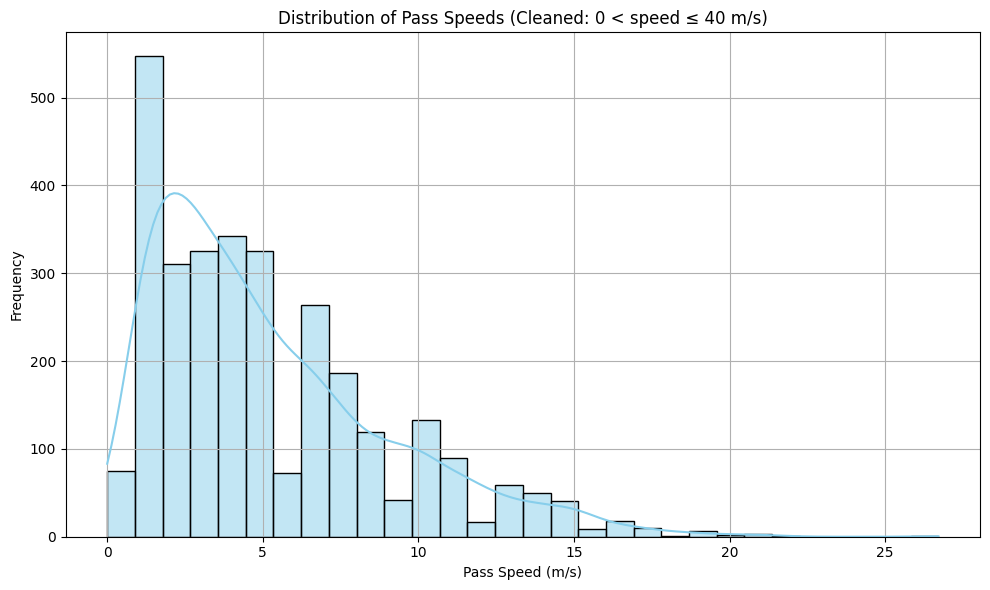

In [62]:
plt.figure(figsize=(10, 6))
sns.histplot(df_passes_cleaned['pass_speed'], bins=30, kde=True, color='skyblue')

plt.title('Distribution of Pass Speeds (Cleaned: 0 < speed ≤ 40 m/s)')
plt.xlabel('Pass Speed (m/s)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()


# The relationship between speed and pressure

In [507]:
df_passes_cleaned = df_passes_cleaned[df_passes_cleaned['passedPlayer_Zone'] != '0.0']
# Construct the mapping dictionary
area_map = {'Defence': 0, 'Mid field': 1, 'Attack': 2}
pass_type_map = {'Backward pass': 0, 'Lateral pass': 1, 'Forward pass': 2}
pressure_dir_map = {'back': 0, 'front': 1}
pressure_level_map = {
    'No Pressure': 0,
    'Limited Pressure': 1,
    'Full Pressure': 2
}

df_passes_cleaned['pass_area_num'] = df_passes_cleaned['passedPlayer_Zone'].map(area_map)
df_passes_cleaned['pass_direction_num'] = df_passes_cleaned['receivedPlayerId_PassType'].map(pass_type_map)
df_passes_cleaned['pressure_direction_num'] = df_passes_cleaned['Pressure direction'].map(pressure_dir_map)
df_passes_cleaned['pressure_level_num'] = df_passes_cleaned['Pressure level'].map(pressure_level_map)


C:\Users\Adolph\AppData\Local\Temp\ipykernel_4184\673138209.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_passes_cleaned['pass_area_num'] = df_passes_cleaned['passedPlayer_Zone'].map(area_map)
C:\Users\Adolph\AppData\Local\Temp\ipykernel_4184\673138209.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_passes_cleaned['pass_direction_num'] = df_passes_cleaned['receivedPlayerId_PassType'].map(pass_type_map)
C:\Users\Adolph\AppData\Local\Temp\ipykernel_4184\673138209.py:14: SettingWithCopyWarnin

In [509]:
from scipy.stats import f_oneway  # only import once at the beginning of your script

# Group pass speeds by pressure levels, dropping missing values
groups = [group['pass_speed'].dropna() for _, group in df_passes_cleaned.groupby('pressure_level_num')]

# Perform one-way ANOVA to test if mean pass speeds differ across pressure levels
f_stat, p_val = f_oneway(*groups)

# Print the F-statistic and p-value
print(f"ANOVA F-statistic = {f_stat:.2f}, p-value = {p_val:.4f}")


ANOVA F-statistic = 7.48, p-value = 0.0006


In [510]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.ols('pass_speed ~ C(pressure_level_num) * C(pressure_direction_num)* C(pass_area_num) * C(pass_direction_num)', data=df_passes_cleaned).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                                                          sum_sq      df  \
C(pressure_level_num)                                 250.081634     2.0   
C(pressure_direction_num)                             148.787515     1.0   
C(pass_area_num)                                      228.364742     2.0   
C(pass_direction_num)                                 142.869859     2.0   
C(pressure_level_num):C(pressure_direction_num)        12.681731     2.0   
C(pressure_level_num):C(pass_area_num)                 17.434784     4.0   
C(pressure_direction_num):C(pass_area_num)             72.068340     2.0   
C(pressure_level_num):C(pass_direction_num)            60.103760     4.0   
C(pressure_direction_num):C(pass_direction_num)       181.712048     2.0   
C(pass_area_num):C(pass_direction_num)                 64.902035     4.0   
C(pressure_level_num):C(pressure_direction_num)...    130.702590     4.0   
C(pressure_level_num):C(pressure_direction_num)...    207.778254     4.0   
C(pressure_l

C:\Users\Adolph\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '


In [514]:
# Extract pass speed data by pressure level
group0 = df_passes_cleaned[df_passes_cleaned['pressure_level_num'] == 0]['pass_speed'].dropna()
group1 = df_passes_cleaned[df_passes_cleaned['pressure_level_num'] == 1]['pass_speed'].dropna()
group2 = df_passes_cleaned[df_passes_cleaned['pressure_level_num'] == 2]['pass_speed'].dropna()

def compute_cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    s1, s2 = g1.std(), g2.std()
    s_pooled = np.sqrt(((n1 - 1)*s1**2 + (n2 - 1)*s2**2) / (n1 + n2 - 2))
    return (g1.mean() - g2.mean()) / s_pooled

# Calculate effect sizes
d_01 = compute_cohens_d(group0, group1)
d_12 = compute_cohens_d(group1, group2)
d_02 = compute_cohens_d(group0, group2)

print(f"Cohen’s d (0 vs 1): {d_01:.3f}")
print(f"Cohen’s d (1 vs 2): {d_12:.3f}")
print(f"Cohen’s d (0 vs 2): {d_02:.3f}")

Cohen’s d (0 vs 1): -0.136
Cohen’s d (1 vs 2): 0.174
Cohen’s d (0 vs 2): 0.029


In [70]:
# Linear regression model: pass speed as a function of tactical factors
model = smf.ols(
    'pass_speed ~ C(pressure_level_num) + C(pressure_direction_num) + C(pass_area_num) + C(pass_direction_num) + receivedPlayerId_PassLength',
    data=df_passes_cleaned
).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             pass_speed   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     38.69
Date:                Sun, 15 Jun 2025   Prob (F-statistic):           4.88e-59
Time:                        01:29:40   Log-Likelihood:                -8187.8
No. Observations:                3023   AIC:                         1.639e+04
Df Residuals:                    3014   BIC:                         1.645e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

C:\Users\Adolph\AppData\Local\Temp\ipykernel_4184\1980604078.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='pressure_level_label', y='predicted_speed', data=df_passes_cleaned, palette='Set2')


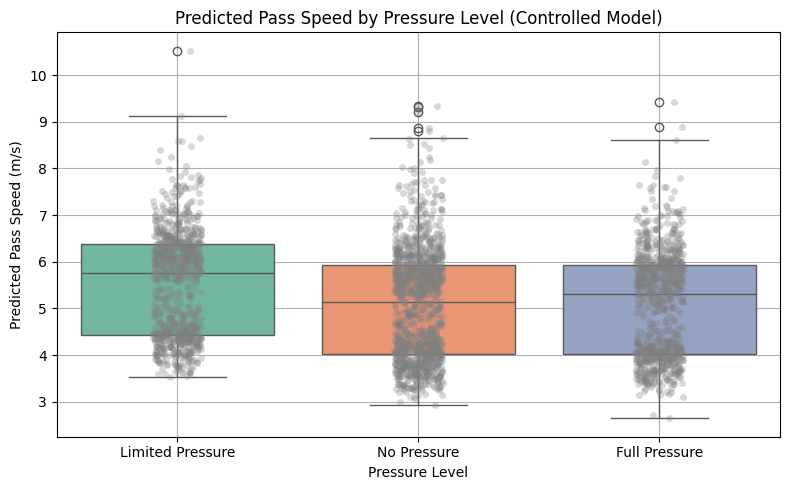

In [72]:

df_passes_cleaned['predicted_speed'] = model.fittedvalues

# Map numeric pressure levels to descriptive labels
pressure_level_labels = {
    0: 'No Pressure',
    1: 'Limited Pressure',
    2: 'Full Pressure'
}
df_passes_cleaned['pressure_level_label'] = df_passes_cleaned['pressure_level_num'].map(pressure_level_labels)

# Create boxplot of predicted pass speed by pressure level
plt.figure(figsize=(8, 5))
sns.boxplot(x='pressure_level_label', y='predicted_speed', data=df_passes_cleaned, palette='Set2')

# Overlay individual data points for better visual clarity
sns.stripplot(x='pressure_level_label', y='predicted_speed', data=df_passes_cleaned, color='gray', alpha=0.3, jitter=True)

plt.title("Predicted Pass Speed by Pressure Level (Controlled Model)")
plt.xlabel("Pressure Level")
plt.ylabel("Predicted Pass Speed (m/s)")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\Adolph\AppData\Local\Temp\ipykernel_4184\3527901461.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.pointplot(x='pressure_level_label', y='predicted_speed', data=df_passes_cleaned, estimator='mean', ci='sd')


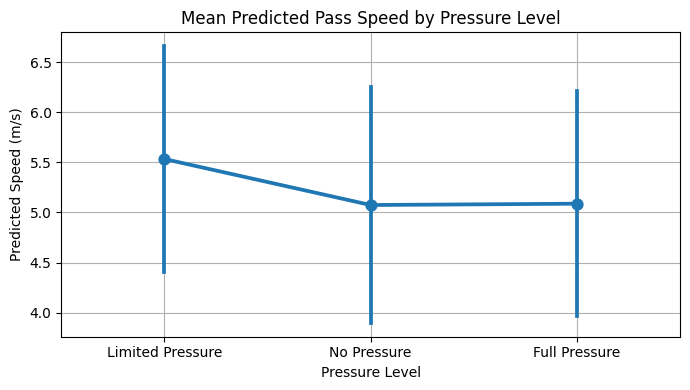

In [73]:
# Line graph
plt.figure(figsize=(7, 4))
sns.pointplot(x='pressure_level_label', y='predicted_speed', data=df_passes_cleaned, estimator='mean', ci='sd')
plt.title("Mean Predicted Pass Speed by Pressure Level")
plt.xlabel("Pressure Level")
plt.ylabel("Predicted Speed (m/s)")
plt.grid(True)
plt.tight_layout()
plt.show()


# The relationship between speed and successful rate and xT

In [76]:
# Convert to lowercase string and strip spaces to ensure consistency
df_passes_cleaned['isSucceeded'] = df_passes_cleaned['isSucceeded'].astype(str).str.strip().str.lower()

# Keep only valid values
valid_values = ['0', '1', '0.0', '1.0']
df_passes_cleaned = df_passes_cleaned[df_passes_cleaned['isSucceeded'].isin(valid_values)]

# Convert to float and then to integer
df_passes_cleaned['isSucceeded'] = df_passes_cleaned['isSucceeded'].astype(float).astype(int)


C:\Users\Adolph\AppData\Local\Temp\ipykernel_4184\2195045.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_passes_cleaned['isSucceeded'] = df_passes_cleaned['isSucceeded'].astype(float).astype(int)


In [78]:
model_logit = smf.logit(
    'isSucceeded ~ pass_speed + receivedPlayerId_PassLength + C(pressure_level_num) + C(pass_area_num) + C(pass_direction_num)',
    data=df_passes_cleaned
).fit(maxiter=100)
print(model_logit.summary())


Optimization terminated successfully.
         Current function value: 0.596262
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:            isSucceeded   No. Observations:                 2983
Model:                          Logit   Df Residuals:                     2974
Method:                           MLE   Df Model:                            8
Date:                Sun, 15 Jun 2025   Pseudo R-squ.:                 0.04784
Time:                        01:32:12   Log-Likelihood:                -1778.6
converged:                       True   LL-Null:                       -1868.0
Covariance Type:            nonrobust   LLR p-value:                 1.896e-34
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       1.1684      0.276      4.230      0.000   

In [176]:
df_passes_cleaned['xT_change'] = df_passes_cleaned['receivedPlayer_xT_gained']
import statsmodels.formula.api as smf

model_xt = smf.ols(
    'xT_change ~ pass_speed + receivedPlayerId_PassLength + C(pressure_level_num) + C(pass_area_num) + C(pass_direction_num)',
    data=df_passes_cleaned
).fit()

print(model_xt.summary())


                            OLS Regression Results                            
Dep. Variable:              xT_change   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.900
Date:                Sun, 15 Jun 2025   Prob (F-statistic):             0.0558
Time:                        03:28:14   Log-Likelihood:                -3924.5
No. Observations:                2957   AIC:                             7867.
Df Residuals:                    2948   BIC:                             7921.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

C:\Users\Adolph\AppData\Local\Temp\ipykernel_4184\2770624173.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_passes_cleaned['xT_change'] = df_passes_cleaned['receivedPlayer_xT_gained']


In [34]:
!pip install pygam

  Using cached numpy-1.24.4-cp38-cp38-win32.whl (12.5 MB)
  Using cached scipy-1.10.1.tar.gz (42.4 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
    Preparing wheel metadata: started
    Preparing wheel metadata: finished with status 'error'


    ERROR: Command errored out with exit status 1:
     command: 'C:\Users\Adolph\anaconda3\python.exe' 'C:\Users\Adolph\anaconda3\lib\site-packages\pip\_vendor\pep517\in_process\_in_process.py' prepare_metadata_for_build_wheel 'C:\Users\Adolph\AppData\Local\Temp\tmpdaz5i0gb'
         cwd: C:\Users\Adolph\AppData\Local\Temp\pip-install-khjv383b\scipy_b2cf084ed3ea4b57a711b783e7e9dd0f
    Complete output (45 lines):
    + meson setup --prefix=C:\Users\Adolph\anaconda3 C:\Users\Adolph\AppData\Local\Temp\pip-install-khjv383b\scipy_b2cf084ed3ea4b57a711b783e7e9dd0f C:\Users\Adolph\AppData\Local\Temp\pip-install-khjv383b\scipy_b2cf084ed3ea4b57a711b783e7e9dd0f\.mesonpy-to93et0h\build --native-file=C:\Users\Adolph\AppData\Local\Temp\pip-install-khjv383b\scipy_b2cf084ed3ea4b57a711b783e7e9dd0f\.mesonpy-native-file.ini -Ddebug=false -Doptimization=2
    The Meson build system
    Version: 1.8.2
    Source dir: C:\Users\Adolph\AppData\Local\Temp\pip-install-khjv383b\scipy_b2cf084ed3ea4b57a711b783e7

C:\Users\Adolph\AppData\Local\Temp\ipykernel_4184\557440387.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_passes_cleaned['xT_change'] = df_passes_cleaned['receivedPlayer_xT_gained']


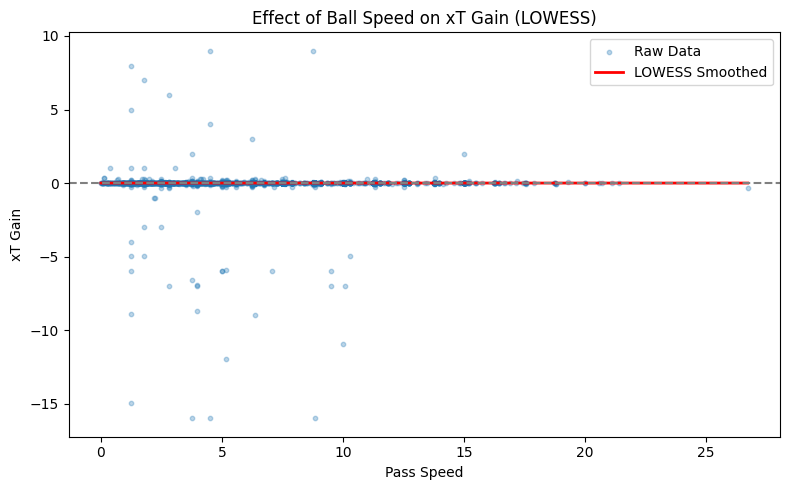

In [83]:
# Assign xT gain value
df_passes_cleaned['xT_change'] = df_passes_cleaned['receivedPlayer_xT_gained']

# Drop missing values
df_plot = df_passes_cleaned[['pass_speed', 'xT_change']].dropna()

# Apply LOWESS smoothing (locally weighted regression)
lowess = sm.nonparametric.lowess
smoothed = lowess(df_plot['xT_change'], df_plot['pass_speed'], frac=0.2)

# Plot scatter and smoothed curve
plt.figure(figsize=(8, 5))
plt.scatter(df_plot['pass_speed'], df_plot['xT_change'], alpha=0.3, label='Raw Data', s=10)
plt.plot(smoothed[:, 0], smoothed[:, 1], color='red', linewidth=2, label='LOWESS Smoothed')
plt.xlabel('Pass Speed')
plt.ylabel('xT Gain')
plt.title('Effect of Ball Speed on xT Gain (LOWESS)')
plt.axhline(0, color='gray', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()


# window analysis

In [98]:
# Keep only successful passes
df = df[df['isSucceeded'] == 1].copy()

# Drop rows with missing values in key columns
required_cols = ['xT_change', 'pass_speed', 'receivedPlayerId_PassLength', 'pressure_level_num']
df = df.dropna(subset=required_cols)

# Map pressure level to score
df['pressure_score'] = df['pressure_level_num'].map({
    0: 0.0,
    1: 0.5,
    2: 1.0
})

# Calculate window score based on multiple features
df['window_score'] = (
    0.4 * (df['xT_change'].clip(0, 0.05) / 0.05) +
    0.25 * (df['pass_speed'].clip(0, 10) / 10) +
    0.2 * (df['receivedPlayerId_PassLength'].clip(0, 20) / 20) +
    0.15 * df['pressure_score']
)

# Label whether the pass qualifies as a tactical window
window_score_threshold = 0.6
df['is_window'] = (df['window_score'] > window_score_threshold).astype(int)


KeyError: 'isSucceeded'

In [143]:
# Created pressure score breakdown
df['pressure_score'] = df['pressure_level_num'].map({
    0: 0.0,
    1: 0.5,
    2: 1.0
})
df['window_score'] = (
    0.4 * (df['xT_change'].clip(0, 0.05) / 0.05) +
    0.25 * (df['pass_speed'].clip(0, 10) / 10) +
    0.2  * (df['receivedPlayerId_PassLength'].clip(0, 20) / 20) +
    0.15 * df['pressure_score']
)

df['is_window'] = (df['window_score'] > 0.6).astype(int)


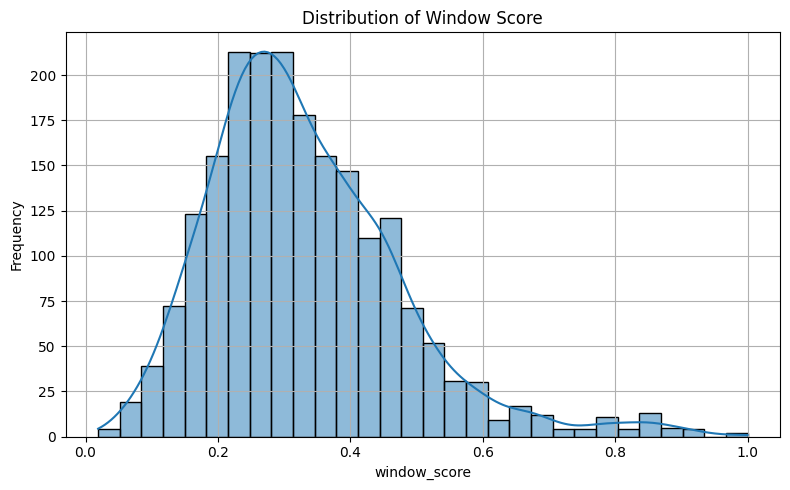

In [255]:
plt.figure(figsize=(8, 5))
sns.histplot(df['window_score'], bins=30, kde=True)
plt.title('Distribution of Window Score')
plt.xlabel('window_score')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()


In [256]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

features = [
    'pass_speed', 'receivedPlayerId_PassLength', 'pressure_level_num',
    'pressure_direction_num', 'pass_area_num', 'pass_direction_num', 'xT_start'
]

df_model = df[features + ['window_score']].dropna()

X = df_model[features]
y = df_model['window_score']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


Mean Squared Error: 0.006957389248491599
R² Score: 0.6588571231505216


In [257]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


features = [
    'pass_speed', 'receivedPlayerId_PassLength', 'pressure_level_num',
    'pressure_direction_num', 'pass_area_num', 'pass_direction_num',
    'xT_start'
]

df_model = df[features + ['window_score']].dropna()
X = df_model[features]
y = df_model['window_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the XGBoost model
reg = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42)
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


MSE: 0.007672120644765933
R² Score: 0.6238115743115611


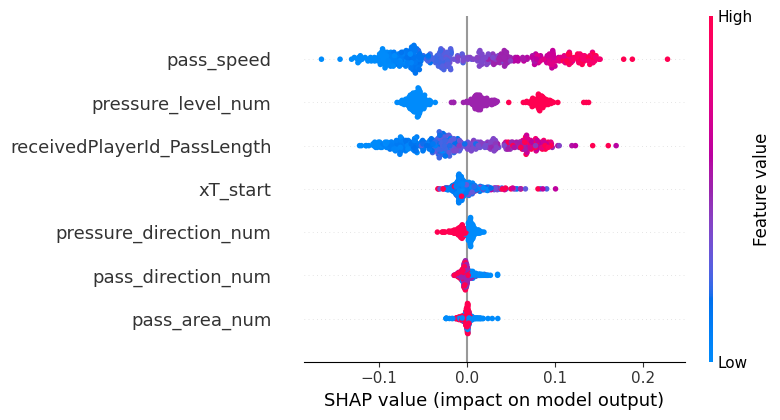

In [258]:
import sys
sys.path.append(r"C:\Users\Adolph\anaconda3\Lib\site-packages")

import shap
explainer = shap.TreeExplainer(reg)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)


In [259]:


def opponent_density_along_path(row):
    x0, y0 = row['passedPlayerPosX'], row['passedPlayerPosY']
    x1, y1 = row['receivedPlayerPosX'], row['receivedPlayerPosY']
    opps = [(row[f'opponentPosX{i}'], row[f'opponentPosY{i}']) for i in range(1,12)]
    
    count = 0
    for ox, oy in opps:
        if ox < 0 or oy < 0:
            continue

        if min(x0, x1) - 2 <= ox <= max(x0, x1) + 2 and min(y0, y1) - 2 <= oy <= max(y0, y1) + 2:
            count += 1
    return count

df['opp_in_path'] = df.apply(opponent_density_along_path, axis=1)


In [261]:
import numpy as np

def point_to_segment_distance(px, py, x1, y1, x2, y2):
    # 计算点(px, py) 到线段(x1,y1)-(x2,y2) 的最短距离
    line_mag = (x2 - x1)**2 + (y2 - y1)**2
    if line_mag == 0:
        return np.sqrt((px - x1)**2 + (py - y1)**2)

    u = ((px - x1) * (x2 - x1) + (py - y1) * (y2 - y1)) / line_mag
    u = max(min(u, 1), 0)
    ix = x1 + u * (x2 - x1)
    iy = y1 + u * (y2 - y1)
    return np.sqrt((px - ix)**2 + (py - iy)**2)

def avg_opp_dist_to_pass_path(row):
    x0, y0 = row['passedPlayerPosX'], row['passedPlayerPosY']
    x1, y1 = row['receivedPlayerPosX'], row['receivedPlayerPosY']
    if x0 < 0 or y0 < 0 or x1 < 0 or y1 < 0:
        return np.nan

    opp_dists = []
    for i in range(1, 12):
        ox, oy = row.get(f'opponentPosX{i}', -1), row.get(f'opponentPosY{i}', -1)
        if ox < 0 or oy < 0:
            continue
        dist = point_to_segment_distance(ox, oy, x0, y0, x1, y1)
        opp_dists.append(dist)

    return np.mean(opp_dists) if opp_dists else np.nan
df['avg_opp_dist_to_path'] = df.apply(avg_opp_dist_to_pass_path, axis=1)


In [263]:
import numpy as np

def calc_pass_opponent_angle(row):
    x0, y0 = row['passedPlayerPosX'], row['passedPlayerPosY']
    x1, y1 = row['receivedPlayerPosX'], row['receivedPlayerPosY']
    
    if x0 < 0 or y0 < 0 or x1 < 0 or y1 < 0:
        return np.nan

    # Compute normalized pass direction vector
    dx_pass, dy_pass = x1 - x0, y1 - y0
    norm_pass = np.sqrt(dx_pass**2 + dy_pass**2)
    if norm_pass == 0:
        return np.nan
    vec_pass = np.array([dx_pass, dy_pass]) / norm_pass

    # Find nearest opponent and compute direction vector
    min_dist = float('inf')
    vec_opp = None
    for i in range(1, 12):
        ox, oy = row.get(f'opponentPosX{i}', -1), row.get(f'opponentPosY{i}', -1)
        if ox < 0 or oy < 0:
            continue
        dx_opp, dy_opp = ox - x0, oy - y0
        dist = np.sqrt(dx_opp**2 + dy_opp**2)
        if 0 < dist < min_dist:
            min_dist = dist
            vec_opp = np.array([dx_opp, dy_opp]) / dist

    if vec_opp is None:
        return np.nan

    # Compute angle (in degrees) between pass and nearest opponent direction
    dot_product = np.dot(vec_pass, vec_opp)
    angle = np.arccos(np.clip(dot_product, -1.0, 1.0))
    return np.degrees(angle)

# Apply to each row
df['angle_pass_vs_nearest_opp'] = df.apply(calc_pass_opponent_angle, axis=1)


In [266]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


features = [
    'pass_speed', 'receivedPlayerId_PassLength', 'pressure_level_num','min_opp_dist',
    'pressure_direction_num', 'pass_area_num', 'pass_direction_num', 'xT_start','opp_in_path', 'angle_pass_vs_nearest_opp'
]

df_model = df[features + ['window_score']].dropna()

X = df_model[features]
y = df_model['window_score']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


Mean Squared Error: 0.006305379682794963
R² Score: 0.680030137963932


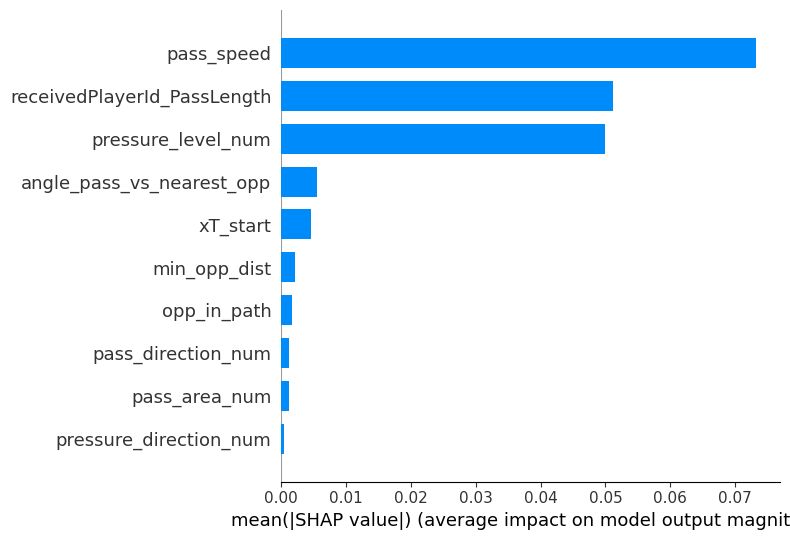

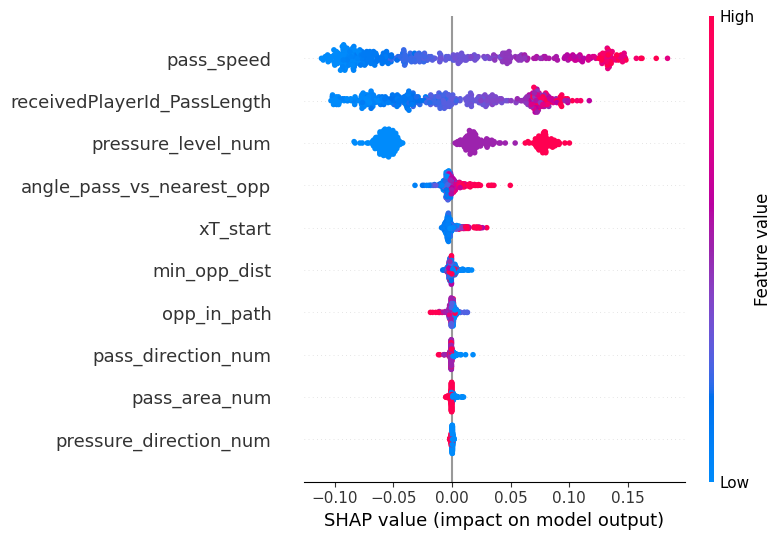

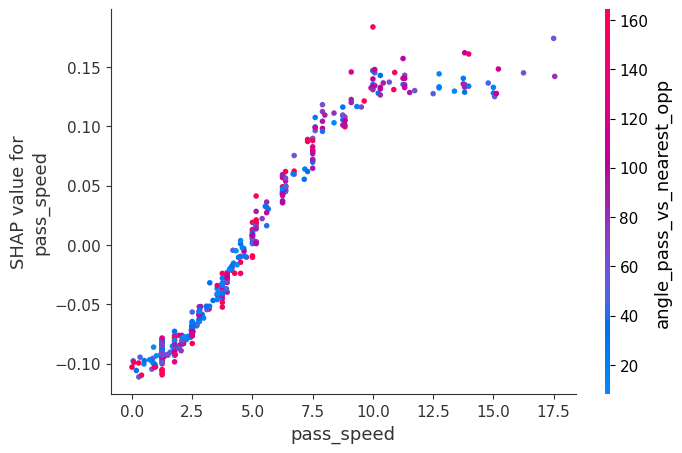

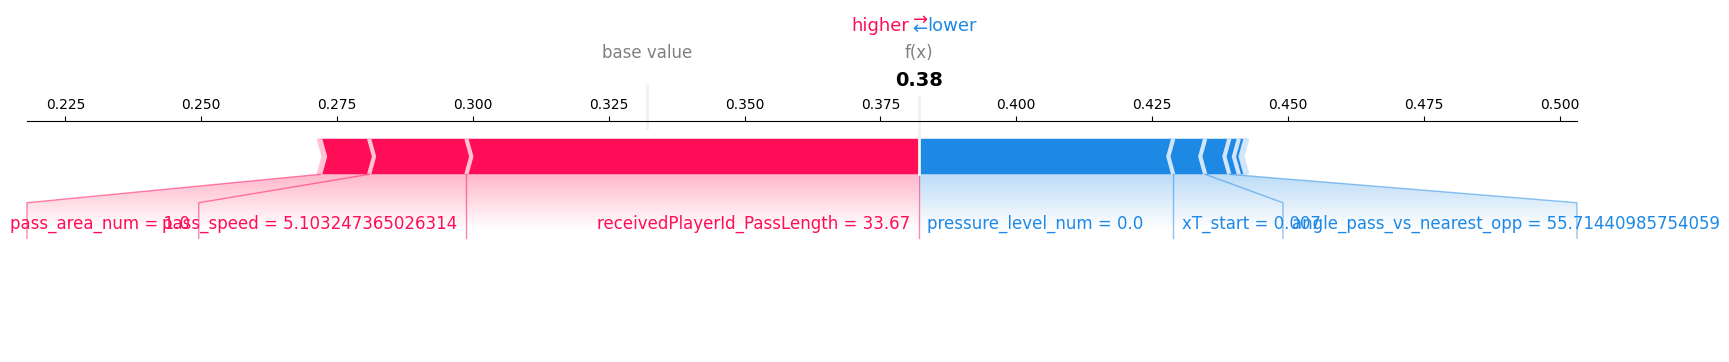

In [267]:
import shap
import matplotlib.pyplot as plt

# 初始化 SHAP 解释器（回归模型）
explainer = shap.TreeExplainer(reg)

# 计算 SHAP 值（这里是直接一维，不需要 [1]）
shap_values = explainer.shap_values(X_test)


shap.summary_plot(shap_values, X_test, plot_type="bar")


shap.summary_plot(shap_values, X_test)


shap.dependence_plot("pass_speed", shap_values, X_test)


shap.force_plot(
    explainer.expected_value,
    shap_values[10],
    X_test.iloc[10],
    matplotlib=True
)


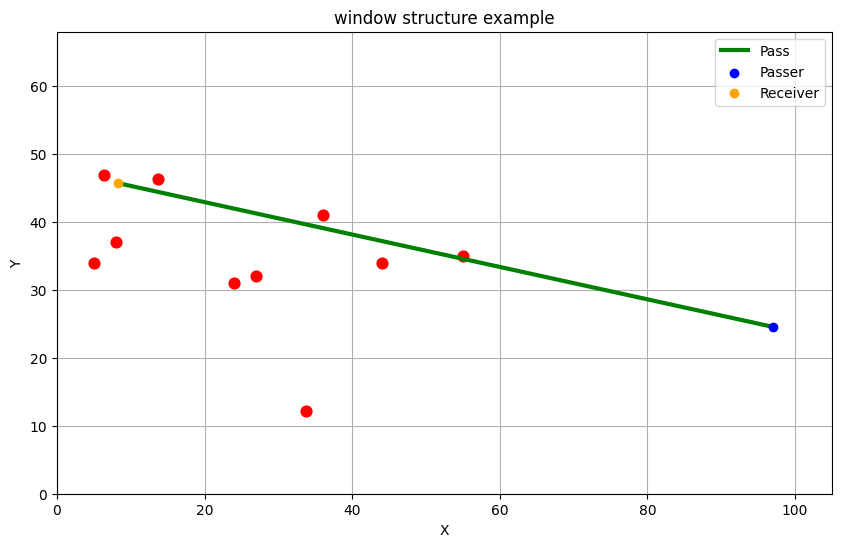

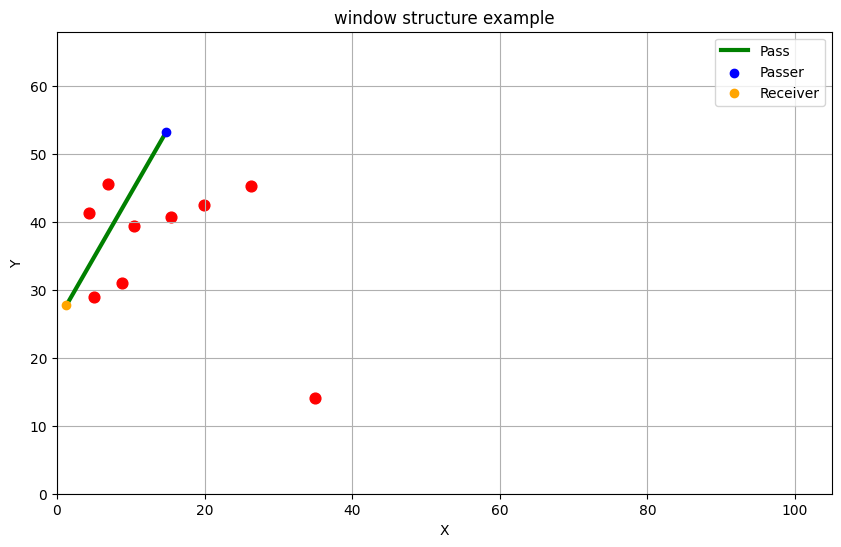

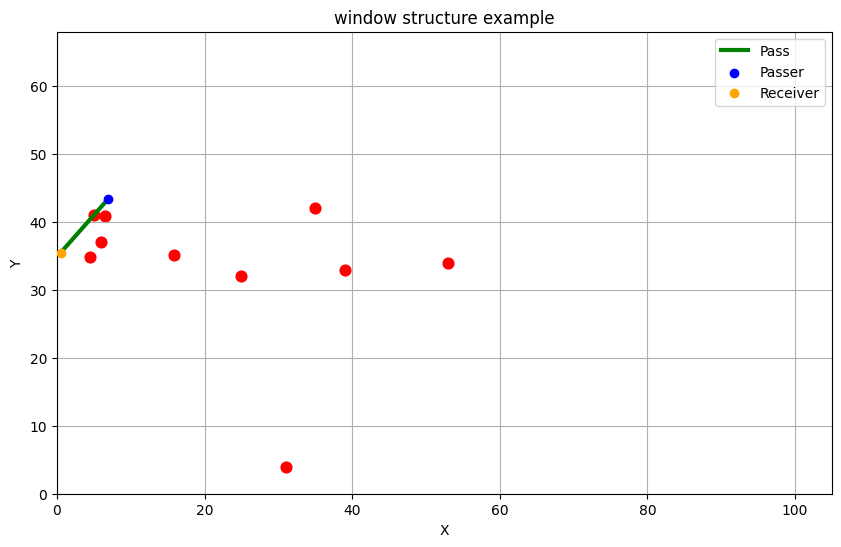

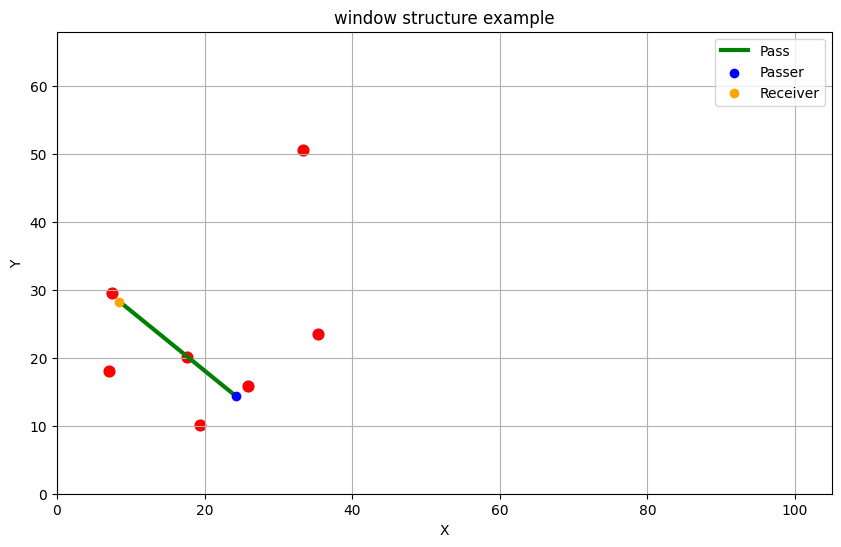

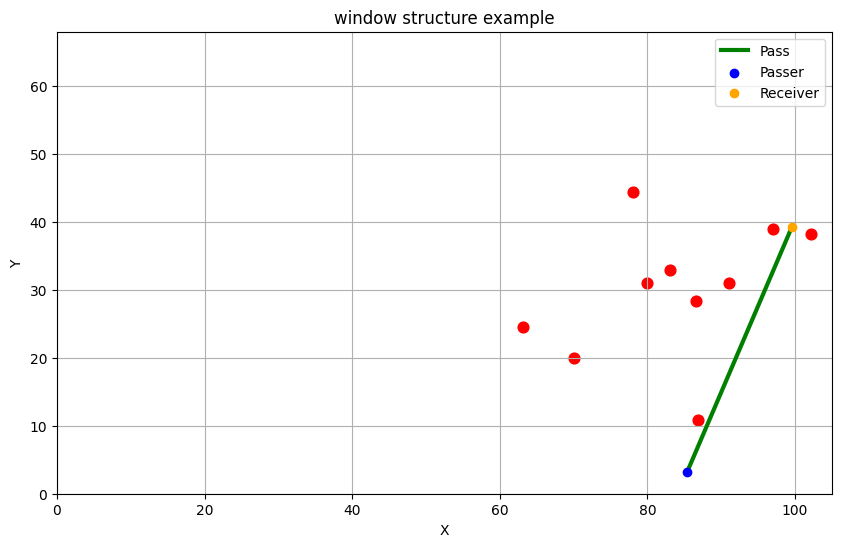

In [268]:
# Select top 5 "window" passes with the clearest space (most opponents in path)
top_structural_windows = df[df['is_window'] == 1].nlargest(5, 'opp_in_path')

# Visualization function: draw pass trajectory and opponent positions
def draw_structure(row):
    plt.figure(figsize=(10, 6))
    plt.xlim(0, 105)
    plt.ylim(0, 68)

    # Draw pass line
    plt.plot(
        [row['passedPlayerPosX'], row['receivedPlayerPosX']],
        [row['passedPlayerPosY'], row['receivedPlayerPosY']],
        color='green', linewidth=3, label='Pass'
    )

    # Draw opponent positions
    for i in range(1, 12):
        ox, oy = row.get(f'opponentPosX{i}'), row.get(f'opponentPosY{i}')
        if ox >= 0 and oy >= 0:
            plt.scatter(ox, oy, color='red', s=60)

    # Draw passer and receiver
    plt.scatter(row['passedPlayerPosX'], row['passedPlayerPosY'], color='blue', label='Passer', zorder=3)
    plt.scatter(row['receivedPlayerPosX'], row['receivedPlayerPosY'], color='orange', label='Receiver', zorder=3)

    plt.title("Window Structure Example")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(True)
    plt.show()

# Visualize the top 5 structural window passes
for i, row in top_structural_windows.iterrows():
    draw_structure(row)


In [243]:
df_window = df[df['window_score'] > df['window_score'].quantile(0.95)].copy()


In [269]:
from sklearn.preprocessing import StandardScaler
import umap
features = [
    'pass_speed', 'receivedPlayerId_PassLength', 'xT_change',
    'opp_in_path', 'angle_pass_vs_nearest_opp', 'min_opp_dist',
    'pressure_level_num', 'pass_area_num', 'pass_direction_num'
]
X = df_window[features].dropna()
X_scaled = scaler.fit_transform(X)


df_window = df_window.loc[X.index].copy()

reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X_scaled)

df_window['umap_x'] = embedding[:, 0]
df_window['umap_y'] = embedding[:, 1]



C:\Users\Adolph\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Adolph\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [270]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df_window['cluster'] = kmeans.fit_predict(X_scaled)


C:\Users\Adolph\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Adolph\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


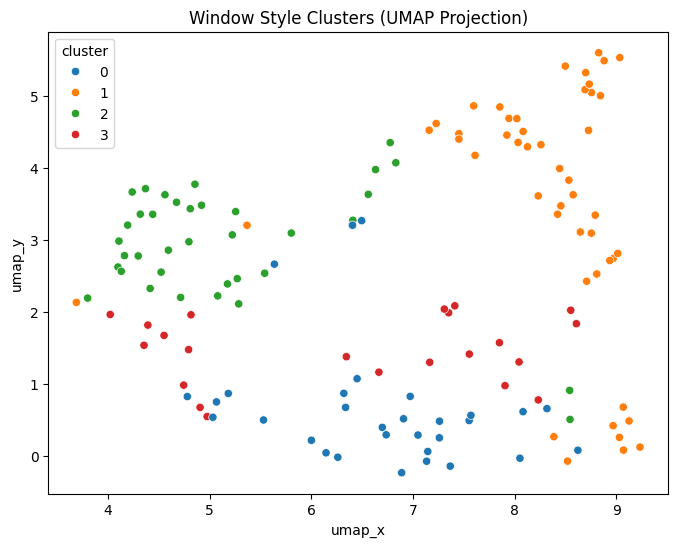

In [271]:
import umap.umap_ as umap
import seaborn as sns
import matplotlib.pyplot as plt

reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X_scaled)

df_window['umap_x'] = embedding[:, 0]
df_window['umap_y'] = embedding[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_window, x='umap_x', y='umap_y', hue='cluster', palette='tab10')
plt.title("Window Style Clusters (UMAP Projection)")
plt.show()


In [272]:
features_for_clustering = [
    'pass_speed', 'receivedPlayerId_PassLength', 'xT_change',
    'opp_in_path', 'angle_pass_vs_nearest_opp', 'min_opp_dist',
    'pressure_level_num', 'pass_area_num', 'pass_direction_num'
]

df_window.groupby('cluster')[features_for_clustering].mean().round(2)


,pass_speed,receivedPlayerId_PassLength,xT_change,opp_in_path,angle_pass_vs_nearest_opp,min_opp_dist,pressure_level_num,pass_area_num,pass_direction_num
cluster,,,,,,,,,
0,10.70,26.96,0.12,1.47,87.89,8.21,1.34,1.72,1.75
1,7.63,15.02,0.19,1.29,130.06,3.32,1.27,1.96,0.17
2,5.22,21.03,0.28,0.89,74.50,10.72,0.75,1.14,0.81
3,5.21,33.15,1.47,4.91,37.83,8.14,1.36,1.59,0.86


# CNN

In [398]:
def extract_frame_players_and_roles(coordinates_df, passes_df, row_idx):
    # Extract pass event row
    row = passes_df.loc[row_idx]
    timestamp = row['normal_time']
    passer_id = row['passedPlayerId']
    team_id = row['passedPlayerTeamId']

    # Get corresponding coordinate frame at the same timestamp
    frame = coordinates_df[coordinates_df['timestamp'] == timestamp]
    if frame.empty:
        raise ValueError(f"No coordinate data found for timestamp {timestamp}")
    frame = frame.iloc[0]

    # Extract all players with valid IDs and positions
    player_rows = []
    for i in range(40):
        pid = frame.get(f'playerId{i}', -100)
        x = frame.get(f'posX{i}', -100)
        y = frame.get(f'posY{i}', -100)
        if pid == -100 or x == -100 or y == -100:
            continue
        player_rows.append({'player_index': i, 'player_id': pid, 'posX': x, 'posY': y})

    df_players = pd.DataFrame(player_rows)

    # Retrieve teammate and opponent IDs from pass record
    teammate_ids = [row.get(f'teamMatePlayerId{i}') for i in range(1, 11)]
    opponent_ids = [row.get(f'opponentPlayerId{i}') for i in range(1, 12)]

    # Assign roles
    df_players['is_passer'] = df_players['player_id'] == passer_id
    df_players['is_teammate'] = df_players['player_id'].isin(teammate_ids)
    df_players['is_opponent'] = df_players['player_id'].isin(opponent_ids)

    return row, df_pl_


In [399]:
def draw_frame_players(df_players, pass_row):
    # Set up pitch display
    plt.figure(figsize=(10, 6.5))
    plt.xlim(0, 105)
    plt.ylim(0, 68)
    plt.gca().set_facecolor('lightgreen')
    plt.title("Spatial Situation at the Time of the Pass", fontsize=14)

    receiver_id = pass_row.get('receivedPlayerId', None)

    # Draw passer
    passer = df_players[df_players['is_passer']]
    plt.scatter(passer['posX'], passer['posY'], color='blue', s=100, label='Passer')

    # Draw teammates (excluding receiver)
    teammates = df_players[df_players['is_teammate'] & (df_players['player_id'] != receiver_id)]
    plt.scatter(teammates['posX'], teammates['posY'], color='white', s=60, label='Teammates')

    # Draw receiver
    receiver = df_players[df_players['player_id'] == receiver_id]
    if not receiver.empty:
        plt.scatter(receiver['posX'], receiver['posY'], color='yellow', edgecolors='black', s=100, label='Receiver', zorder=5)

    # Draw opponents
    opponents = df_players[df_players['is_opponent']]
    plt.scatter(opponents['posX'], opponents['posY'], color='black', s=60, label='Opponents')

    # Annotate player IDs
    for _, row in df_players.iterrows():
        if pd.notna(row['player_id']):
            plt.text(row['posX'], row['posY'] + 1, str(int(row['player_id'])), fontsize=8, ha='center')

    # Draw pass arrow from passer to receiver
    try:
        passer_row = df_players[df_players['is_passer']].iloc[0]
        receiver_row = df_players[df_players['player_id'] == receiver_id].iloc[0]

        plt.arrow(
            passer_row['posX'], passer_row['posY'],
            receiver_row['posX'] - passer_row['posX'],
            receiver_row['posY'] - passer_row['posY'],
            width=0.3, head_width=2.2, length_includes_head=True, color='red', alpha=0.9
        )
    except:
        pass

    plt.xlabel("Field X")
    plt.ylabel("Field Y")
    plt.legend()
    plt.grid(True)
    plt.show()


In [18]:
pass_row, frame_players = extract_frame_players_and_roles(df_coordinates, df_passes, 20)
draw_frame_players(frame_players, pass_row)


NameError: name 'extract_frame_players_and_roles' is not defined

In [476]:
# Image save path and quantity
save_dir = r"C:\Users\Adolph\graduation thesis\image"
os.makedirs(save_dir, exist_ok=True)
num_samples = 500  # Number of images to generate

# Function to draw spatial pass frame and save as image
def draw_pass_frame_as_image(df_players, pass_row, save_path):
    plt.figure(figsize=(10, 6.5))
    plt.xlim(0, 105)
    plt.ylim(0, 68)
    plt.gca().set_facecolor('lightgreen')
    plt.title("Spatial Situation at the Time of the Pass", fontsize=14)

    receiver_id = pass_row.get('receivedPlayerId', None)

    # Plot players
    passer = df_players[df_players['is_passer']]
    plt.scatter(passer['posX'], passer['posY'], color='blue', s=100, label='Passer')

    teammates = df_players[df_players['is_teammate'] & (df_players['player_id'] != receiver_id)]
    plt.scatter(teammates['posX'], teammates['posY'], color='white', s=60, label='Teammates')

    receiver = df_players[df_players['player_id'] == receiver_id]
    if not receiver.empty:
        plt.scatter(receiver['posX'], receiver['posY'], color='yellow', edgecolors='black', s=100, label='Receiver', zorder=5)

    opponents = df_players[df_players['is_opponent']]
    plt.scatter(opponents['posX'], opponents['posY'], color='black', s=60, label='Opponents')

    # Annotate player IDs
    for _, row in df_players.iterrows():
        if pd.notna(row['player_id']):
            plt.text(row['posX'], row['posY'] + 1, str(int(row['player_id'])), fontsize=8, ha='center')

    # Draw pass arrow
    try:
        passer_row = passer.iloc[0]
        receiver_row = receiver.iloc[0]
        plt.arrow(
            passer_row['posX'], passer_row['posY'],
            receiver_row['posX'] - passer_row['posX'],
            receiver_row['posY'] - passer_row['posY'],
            width=0.3, head_width=2.2, length_includes_head=True, color='red', alpha=0.9
        )
    except:
        pass

    plt.xlabel("Field X")
    plt.ylabel("Field Y")
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0.1)
    plt.close()

# Generate images and labels
label_rows = []
count = 0

for idx in range(num_samples):
    try:
        pass_row, df_players = extract_frame_players_and_roles(df_coordinates, df_passes_cleaned, idx)

        # Save image
        img_name = f"pass_{idx:04d}.png"
        img_path = os.path.join(save_dir, img_name)
        draw_pass_frame_as_image(df_players, pass_row, img_path)

        # Compute window score
        xt = pass_row.get('xT_change', np.nan)
        speed = pass_row.get('pass_speed', np.nan)
        dist = pass_row.get('receivedPlayerId_PassLength', np.nan)
        pressure = pass_row.get('pressure_level_num', 0)

        window_score = (
            0.4 * (np.clip(xt, 0, 0.05) / 0.05) +
            0.25 * (np.clip(speed, 0, 10) / 10) +
            0.2  * (np.clip(dist, 0, 20) / 20) +
            0.15 * pressure
        )

        label_rows.append({
            'filename': img_name,
            'window_score': round(window_score, 4),
            'xT_change': xt,
            'isSucceeded': pass_row.get('isSucceeded', 0)
        })

        count += 1

    except:
        continue

# Save label file
df_labels = pd.DataFrame(label_rows)
csv_path = os.path.join(save_dir, "pass_labels_window_xt.csv")
df_labels.to_csv(csv_path, index=False)

print(f"Images generated: {count}")
print(f"Label CSV saved to: {csv_path}")
print(df_labels.head())


 image produced：471 
 C:\Users\Adolph\graduation thesis\image\pass_labels_window_xt.csv
        filename  window_score  xT_change  isSucceeded
0  pass_0000.png        0.4946     -0.001            0
1  pass_0001.png        0.3001      0.004            1
2  pass_0002.png        0.4703     -0.003            0
3  pass_0003.png        0.2101     -0.007            1
4  pass_0004.png        0.2477      0.001            1


In [497]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# define image and label paths
image_dir = r"C:\Users\Adolph\graduation thesis\image"
label_path = os.path.join(image_dir, "pass_labels_window_xt.csv")
df = pd.read_csv(label_path)

# clean labels
df = df.dropna(subset=['xT_change', 'window_score'])
df = df[(df['xT_change'] >= -1) & (df['xT_change'] <= 1)]

# train-validation split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# image data generator with multitask labels
class PassDataset(Sequence):
    def __init__(self, df, batch_size=32, image_size=(224, 224), shuffle=True):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.image_size = image_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index*self.batch_size:(index+1)*self.batch_size]
        batch_df = self.df.iloc[batch_indices]

        images, ws_labels, xt_labels, succ_labels = [], [], [], []

        for _, row in batch_df.iterrows():
            img_path = os.path.join(image_dir, row['filename'])
            img = load_img(img_path, target_size=self.image_size)
            img_array = img_to_array(img) / 255.0

            images.append(img_array)
            ws_labels.append(row['window_score'])
            xt_labels.append(row['xT_change'])
            succ_labels.append(row['isSucceeded'])

        return np.array(images), {
            'window_score': np.array(ws_labels, dtype=np.float32),
            'xT_change': np.array(xt_labels, dtype=np.float32),
            'isSucceeded': np.array(succ_labels, dtype=np.float32)
        }

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# initialize data generators
train_gen = PassDataset(train_df, batch_size=16)
val_gen = PassDataset(val_df, batch_size=16, shuffle=False)

# define CNN model with multitask outputs
def build_model(input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), activation='relu')(inputs)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(64, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(128, (3,3), activation='relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)

    out_window = layers.Dense(1, name='window_score')(x)
    out_xt = layers.Dense(1, name='xT_change')(x)
    out_success = layers.Dense(1, activation='sigmoid', name='isSucceeded')(x)

    model = models.Model(inputs=inputs, outputs=[out_window, out_xt, out_success])
    return model

# compile model with loss and metrics per task
optimizer = optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)
model = build_model()
model.compile(
    optimizer=optimizer,
    loss={
        'window_score': losses.MeanSquaredError(),
        'xT_change': losses.MeanSquaredError(),
        'isSucceeded': losses.BinaryCrossentropy()
    },
    metrics={
        'window_score': metrics.MeanAbsoluteError(),
        'xT_change': metrics.MeanAbsoluteError(),
        'isSucceeded': metrics.BinaryAccuracy()
    }
)

# train model with early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=3,
    callbacks=[early_stop],
    verbose=1
)

# save model weights
model.save_weights("cnn_pass.weights.h5")


C:\Users\Adolph\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 390ms/step - isSucceeded_binary_accuracy: 0.4776 - isSucceeded_loss: 0.6937 - loss: 0.7781 - window_score_loss: 0.0803 - window_score_mean_absolute_error: 0.2269 - xT_change_loss: 0.0039 - xT_change_mean_absolute_error: 0.0323 - val_isSucceeded_binary_accuracy: 0.6452 - val_isSucceeded_loss: 0.6717 - val_loss: 0.7127 - val_window_score_loss: 0.0404 - val_window_score_mean_absolute_error: 0.1614 - val_xT_change_loss: 0.0013 - val_xT_change_mean_absolute_error: 0.0282
Epoch 2/3
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 359ms/step - isSucceeded_binary_accuracy: 0.6313 - isSucceeded_loss: 0.6703 - loss: 0.7167 - window_score_loss: 0.0425 - window_score_mean_absolute_error: 0.1647 - xT_change_loss: 0.0190 - xT_change_mean_absolute_error: 0.0319 - val_isSucceeded_binary_accuracy: 0.6452 - val_isSucceeded_loss: 0.6568 - val_loss: 0.6905 - val_window_score_loss: 0.0332 - val_window_score_mean_absolute_error: 0.1436 - val_xT_change_loss: 0.0014 - val_xT_change_mean_

In [481]:
predict_dir = r"C:\Users\Adolph\graduation thesis\predict"
os.makedirs(predict_dir, exist_ok=True)

start_idx = 2000
end_idx = 2100 

predict_filenames = []

for idx in range(start_idx, end_idx):
    try:
        pass_row, df_players = extract_frame_players_and_roles(df_coordinates, df_passes_cleaned, idx)
        img_name = f"pass_predict_{idx}.png"
        save_path = os.path.join(predict_dir, img_name)
        draw_pass_frame_as_image(df_players, pass_row, save_path)
        predict_filenames.append(img_name)
    except:
        continue

print(f"image produced：{len(predict_filenames)} ")


image produced：91 


In [501]:
from tensorflow.keras.models import load_model

# Define paths
predict_dir = r"C:\Users\Adolph\graduation thesis\predict"
model_path = os.path.join(predict_dir, '..', 'image', 'cnn_pass_model.h5')
output_csv = os.path.join(predict_dir, 'predictions.csv')

# Load trained model and weights
model = build_model()
model.load_weights("cnn_pass.weights.h5")

# Get image file list
image_files = [f for f in os.listdir(predict_dir) if f.endswith('.png')]
image_files.sort()

# Set image size
image_size = (224, 224)

# Store predictions
rows = []

for fname in image_files:
    img_path = os.path.join(predict_dir, fname)
    img = load_img(img_path, target_size=image_size)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # shape: (1, 224, 224, 3)

    # Run prediction
    preds = model.predict(img_array, verbose=0)
    pred_window = preds[0][0][0]
    pred_xt = preds[1][0][0]
    pred_succ = preds[2][0][0]

    rows.append({
        'filename': fname,
        'pred_window_score': float(pred_window),
        'pred_xT_change': float(pred_xt),
        'pred_isSucceeded_prob': float(pred_succ)
    })

# Save results to CSV
df_pred = pd.DataFrame(rows)
df_pred.to_csv(output_csv, index=False)
print(df_pred.head())


                filename  pred_window_score  pred_xT_change  \
0  pass_predict_2000.png           0.396825        0.003681   
1  pass_predict_2001.png           0.396677        0.003681   
2  pass_predict_2002.png           0.396670        0.003744   
3  pass_predict_2003.png           0.397275        0.003657   
4  pass_predict_2004.png           0.396423        0.003749   

   pred_isSucceeded_prob  
0               0.642410  
1               0.642365  
2               0.642369  
3               0.642580  
4               0.642266  


Models judge the smoothest passes：
                 filename  pred_window_score  pred_xT_change  \
93  pass_predict_2188.png           0.398877        0.003378   
7   pass_predict_2007.png           0.397803        0.003481   
54  pass_predict_2059.png           0.397802        0.003520   
82  pass_predict_2090.png           0.397730        0.003580   
96  pass_predict_2191.png           0.397710        0.003509   

    pred_isSucceeded_prob  
93               0.643134  
7                0.642786  
54               0.642793  
82               0.642752  
96               0.642748  
图像：pass_predict_2188.png, window_score=0.3989


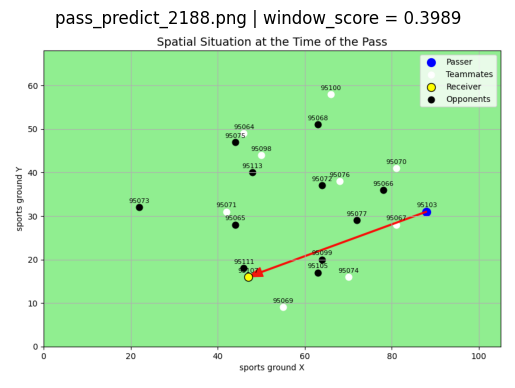

图像：pass_predict_2007.png, window_score=0.3978


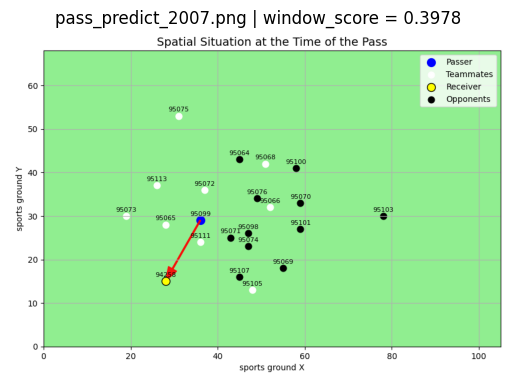

图像：pass_predict_2059.png, window_score=0.3978


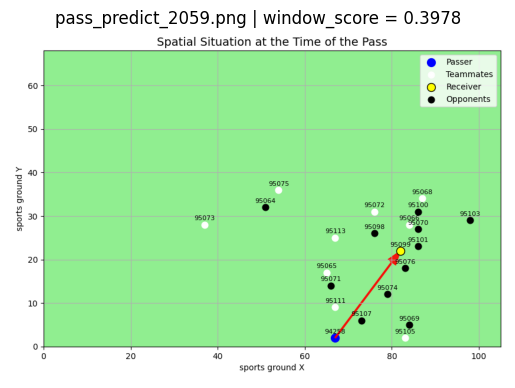

In [502]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image


predict_dir = r"C:\Users\Adolph\graduation thesis\predict"
csv_path = os.path.join(predict_dir, "predictions.csv")


df_pred = pd.read_csv(csv_path)
df_sorted = df_pred.sort_values("pred_window_score", ascending=False)


print("Models judge the smoothest passes：")
print(df_sorted.head())


for i in range(3):
    fname = df_sorted.iloc[i]["filename"]
    score = df_sorted.iloc[i]["pred_window_score"]
    print(f"图像：{fname}, window_score={score:.4f}")
    img_path = os.path.join(predict_dir, fname)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"{fname} | window_score = {score:.4f}")
    plt.axis("off")
    plt.show()


 image：pass_predict_2188.png
  window_score：0.399
  xT_change    ：0.003
  successul rate     ：0.643



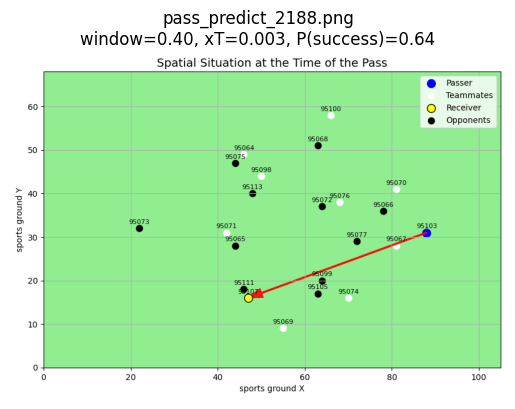

 image：pass_predict_2007.png
  window_score：0.398
  xT_change    ：0.003
  successul rate     ：0.643



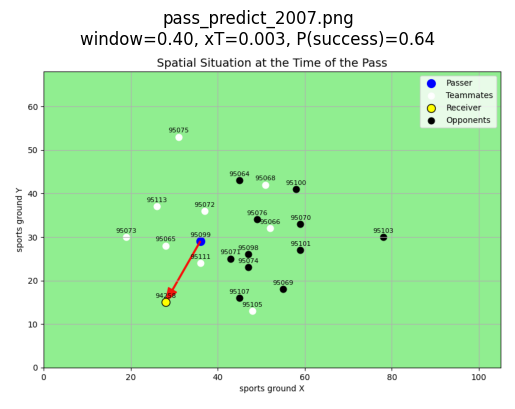

 image：pass_predict_2059.png
  window_score：0.398
  xT_change    ：0.004
  successul rate     ：0.643



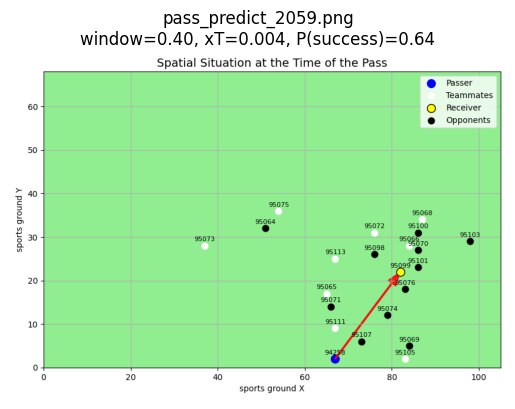

In [503]:
for i in range(3):
    row = df_sorted.iloc[i]
    print(f" image：{row['filename']}")
    print(f"  window_score：{row['pred_window_score']:.3f}")
    print(f"  xT_change    ：{row['pred_xT_change']:.3f}")
    print(f"  successul rate     ：{row['pred_isSucceeded_prob']:.3f}")
    print("")

    img_path = os.path.join(predict_dir, row['filename'])
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"{row['filename']}\nwindow={row['pred_window_score']:.2f}, xT={row['pred_xT_change']:.3f}, P(success)={row['pred_isSucceeded_prob']:.2f}")
    plt.axis("off")
    plt.show()


# 新开一章 调整论文中心主题 how to identity a good pass?

In [52]:
import pandas as pd
import os

# List of match folder names
match_folders = ['match1', 'match2', 'match3', 'match4', 'match5']

# Initialize empty lists to store DataFrames from each folder
coordinates_list = []
passes_list = []

# Loop through each match folder and read the corresponding CSV files
for folder in match_folders:
    coordinates_path = os.path.join(folder, 'coordinates.csv')
    passes_path = os.path.join(folder, 'passes.csv')
    
    if os.path.exists(coordinates_path):
        df_coord = pd.read_csv(coordinates_path)
        df_coord['match'] = folder  # Add match identifier column
        coordinates_list.append(df_coord)

    if os.path.exists(passes_path):
        df_pass = pd.read_csv(passes_path)
        df_pass['match'] = folder  # Add match identifier column
        passes_list.append(df_pass)

# Concatenate all match DataFrames into a single DataFrame
all_coordinates = pd.concat(coordinates_list, ignore_index=True)
all_passes = pd.concat(passes_list, ignore_index=True)

# Write the merged DataFrames into an Excel file with two sheets
output_path = 'merged_matches.xlsx'
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    all_coordinates.to_excel(writer, sheet_name='coordinates', index=False)
    all_passes.to_excel(writer, sheet_name='passes', index=False)

print(f'Saved as {output_path}')


Saved as merged_matches.xlsx


In [53]:
df_passes = pd.read_excel('merged_matches.xlsx', sheet_name='passes')
df_passes['timestamp'] = pd.to_datetime(df_passes['timestamp'], unit='ms')
df_coordinates = pd.read_excel('merged_matches.xlsx', sheet_name='coordinates', parse_dates=['timestamp'])


# Calculate Speed

In [55]:
import numpy as np

# Ensure the coordinates table is sorted by timestamp
df_coordinates = df_coordinates.sort_values('timestamp')

# Define a function to compute pass speed from coordinates
def compute_pass_speed_from_coordinates(pass_time):
    # Find the index of the current pass timestamp in the coordinates table
    i = df_coordinates['timestamp'].searchsorted(pass_time)
    
    # If the index is out of range, return NaN
    if i >= len(df_coordinates) - 1:
        return np.nan

    x1, y1 = df_coordinates.iloc[i]['ballposX'], df_coordinates.iloc[i]['ballposY']
    t1 = df_coordinates.iloc[i]['timestamp']
    
    x2, y2 = df_coordinates.iloc[i+4]['ballposX'], df_coordinates.iloc[i+1]['ballposY']  # mixed step
    t2 = df_coordinates.iloc[i+4]['timestamp']
    
    # Time difference
    dt = (t2 - t1).total_seconds()
    if dt == 0:
        return np.nan
    
    # Euclidean distance
    dist = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

    return dist / dt

# Apply the speed calculation to each pass event
df_passes['pass_speed'] = df_passes['timestamp'].apply(compute_pass_speed_from_coordinates)


In [58]:
# Remove ball speeds = 0 or > 40
df_passes_cleaned = df_passes[
    (df_passes['pass_speed'] > 0) & (df_passes['pass_speed'] <= 40)
].copy()

In [59]:
df_passes_cleaned = df_passes_cleaned[df_passes_cleaned['passedPlayer_Zone'] != '0.0']
# Construct the mapping dictionary
area_map = {'Defence': 0, 'Mid field': 1, 'Attack': 2}
pass_type_map = {'Backward pass': 0, 'Lateral pass': 1, 'Forward pass': 2}
pressure_dir_map = {'back': 0, 'front': 1}
pressure_level_map = {
    'No Pressure': 0,
    'Limited Pressure': 1,
    'Full Pressure': 2
}

df_passes_cleaned['pass_area_num'] = df_passes_cleaned['passedPlayer_Zone'].map(area_map)
df_passes_cleaned['pass_direction_num'] = df_passes_cleaned['receivedPlayerId_PassType'].map(pass_type_map)
df_passes_cleaned['pressure_direction_num'] = df_passes_cleaned['Pressure direction'].map(pressure_dir_map)
df_passes_cleaned['pressure_level_num'] = df_passes_cleaned['Pressure level'].map(pressure_level_map)


# 构建window_score

In [17]:
df=df_passes_cleaned.copy()

df['xT_change'] = df['receivedPlayer_xT_gained']


# Drop rows with missing values in key columns
required_cols = ['xT_change', 'pass_speed', 'receivedPlayerId_PassLength', 'pressure_level_num']
df = df.dropna(subset=required_cols)

# Map pressure level to score
df['pressure_score'] = df['pressure_level_num'].map({
    0: 0.0,
    1: 0.5,
    2: 1.0
})

# Calculate window score based on multiple features
df['window_score'] = (
    0.4 * (df['xT_change'].clip(0, 0.05) / 0.05) +
    0.25 * (df['pass_speed'].clip(0, 10) / 10) +
    0.2 * (df['receivedPlayerId_PassLength'].clip(0, 15) / 15) +
    0.15 * df['pressure_score']
)

# Label whether the pass qualifies as a tactical window
window_score_threshold = 0.6
df['is_window'] = (df['window_score'] > window_score_threshold).astype(int)


NameError: name 'df_passes_cleaned' is not defined

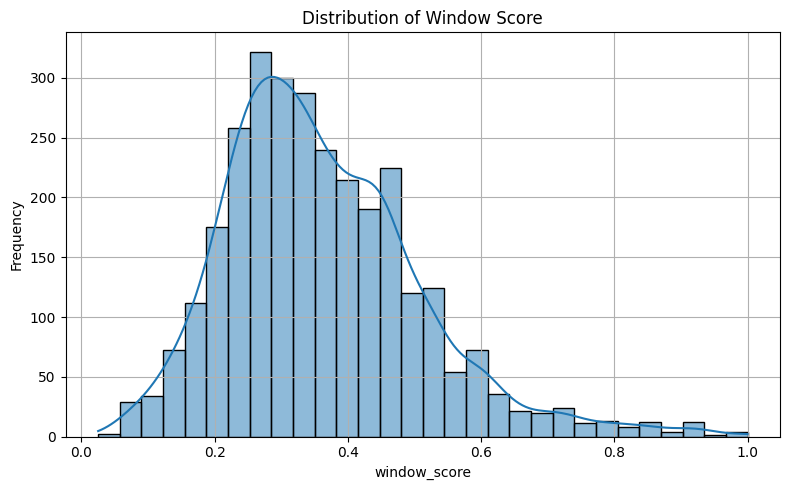

In [153]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
sns.histplot(df['window_score'], bins=30, kde=True)
plt.title('Distribution of Window Score')
plt.xlabel('window_score')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()


In [154]:
df['is_valuable'] = (df['window_score'] > 0.6).astype(int)
print(df['is_valuable'].value_counts())

is_valuable
0    2820
1     177
Name: count, dtype: int64


# 抽样人工打标

In [69]:
# 假设你之前的 df 里包含 window_score、xT_change、pass_speed 等字段
df = df.copy()

# 分段抽样
df_top = df[df['window_score'] > 0.6].sample(n=40, random_state=1)
df_mid = df[(df['window_score'] <= 0.6) & (df['window_score'] >= 0.4)].sample(n=30, random_state=2)
df_low = df[df['window_score'] < 0.4].sample(n=30, random_state=3)

# 合并并打乱顺序
df_label_sample = pd.concat([df_top, df_mid, df_low]).sample(frac=1.0, random_state=42).reset_index(drop=True)

# 添加空列用于打标
df_label_sample["human_label"] = ""

# 选取需要保存的列
columns_to_save = ["window_score",  'pass_speed', 'receivedPlayerId_PassLength', 'pressure_level_num',
    'pressure_direction_num', 'pass_area_num', 'pass_direction_num', 'xT_change','opp_in_path','avg_opp_dist_to_path','angle_pass_vs_nearest_opp']
df_label_sample[columns_to_save].to_csv("label_annotation_sample.csv", index=False)


# 计算人工打标和window_score判断是否有价值的一致性

In [26]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


file_path = "label_annotation_sample .csv"  # 请确保文件路径正确
df = pd.read_csv(file_path)


df = df.dropna(subset=["human_label"])  # 删除未标注的行
df["human_label"] = df["human_label"].astype(int)  # 转为整数型


df["system_label"] = (df["window_score"] > 0.6).astype(int)


accuracy = accuracy_score(df["human_label"], df["system_label"])
report = classification_report(df["human_label"], df["system_label"])
conf_matrix = confusion_matrix(df["human_label"], df["system_label"])


print(f"accuracy：{accuracy:.2%}")
print("\nclassification_report：")
print(report)
print("confusion_matrix：")
print(conf_matrix)


accuracy：94.00%

classification_report：
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        50
           1       1.00      0.88      0.94        50

    accuracy                           0.94       100
   macro avg       0.95      0.94      0.94       100
weighted avg       0.95      0.94      0.94       100

confusion_matrix：
[[50  0]
 [ 6 44]]


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 特征列
features = [
    'pass_speed', 'receivedPlayerId_PassLength', 'pressure_level_num',
    'pressure_direction_num', 'pass_area_num', 'pass_direction_num', 'xT_change'
]

# 过滤缺失值
df_model = df[features + ['is_valuable']].dropna()

X = df_model[features]
y = df_model['is_valuable'].astype(int)  # 确保标签是整数型（0/1）

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 定义分类模型
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
clf.fit(X_train, y_train)

# 预测并评估
y_pred = clf.predict(X_test)

print("(Accuracy):", accuracy_score(y_test, y_pred))
print("\n (Classification Report):\n", classification_report(y_test, y_pred))
print(" (Confusion Matrix):\n", confusion_matrix(y_test, y_pred))


(Accuracy): 0.98

 (Classification Report):
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       567
           1       0.96      0.67      0.79        33

    accuracy                           0.98       600
   macro avg       0.97      0.83      0.89       600
weighted avg       0.98      0.98      0.98       600

 (Confusion Matrix):
 [[566   1]
 [ 11  22]]


In [34]:
print("总数据量：", len(df))
print(df["is_valuable"].value_counts())


总数据量： 2997
is_valuable
0    2820
1     177
Name: count, dtype: int64


In [16]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# 你的特征列表
features = [
    'pass_speed', 'receivedPlayerId_PassLength', 'pressure_level_num',
    'pressure_direction_num', 'pass_area_num', 'pass_direction_num', 'xT_change', 'opp_in_path','avg_opp_dist_to_path','angle_pass_vs_nearest_opp'
]

# 准备数据
df_model = df[features + ['is_valuable']].dropna()
X = df_model[features]
y = df_model['is_valuable'].astype(int)

# 划分训练/测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

weight_ratio = (y == 0).sum() / (y == 1).sum()

# 定义 XGBoost 分类器
clf = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=weight_ratio,
    random_state=42
)

# 训练模型
clf.fit(X_train, y_train)

# 预测
y_pred = clf.predict(X_test)

# 评估
print("准确率 (Accuracy):", accuracy_score(y_test, y_pred))
print("\n分类报告 (Classification Report):\n", classification_report(y_test, y_pred))
print("混淆矩阵 (Confusion Matrix):\n", confusion_matrix(y_test, y_pred))


NameError: name 'df' is not defined

In [ ]:
import sys
sys.path.append(r"C:\Users\Adolph\anaconda3\Lib\site-packages")

import shap
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)


In [66]:


def opponent_density_along_path(row):
    x0, y0 = row['passedPlayerPosX'], row['passedPlayerPosY']
    x1, y1 = row['receivedPlayerPosX'], row['receivedPlayerPosY']
    opps = [(row[f'opponentPosX{i}'], row[f'opponentPosY{i}']) for i in range(1,12)]
    
    count = 0
    for ox, oy in opps:
        if ox < 0 or oy < 0:
            continue

        if min(x0, x1) - 2 <= ox <= max(x0, x1) + 2 and min(y0, y1) - 2 <= oy <= max(y0, y1) + 2:
            count += 1
    return count

df['opp_in_path'] = df.apply(opponent_density_along_path, axis=1)


In [67]:
import numpy as np

def point_to_segment_distance(px, py, x1, y1, x2, y2):
    # 计算点(px, py) 到线段(x1,y1)-(x2,y2) 的最短距离
    line_mag = (x2 - x1)**2 + (y2 - y1)**2
    if line_mag == 0:
        return np.sqrt((px - x1)**2 + (py - y1)**2)

    u = ((px - x1) * (x2 - x1) + (py - y1) * (y2 - y1)) / line_mag
    u = max(min(u, 1), 0)
    ix = x1 + u * (x2 - x1)
    iy = y1 + u * (y2 - y1)
    return np.sqrt((px - ix)**2 + (py - iy)**2)

def avg_opp_dist_to_pass_path(row):
    x0, y0 = row['passedPlayerPosX'], row['passedPlayerPosY']
    x1, y1 = row['receivedPlayerPosX'], row['receivedPlayerPosY']
    if x0 < 0 or y0 < 0 or x1 < 0 or y1 < 0:
        return np.nan

    opp_dists = []
    for i in range(1, 12):
        ox, oy = row.get(f'opponentPosX{i}', -1), row.get(f'opponentPosY{i}', -1)
        if ox < 0 or oy < 0:
            continue
        dist = point_to_segment_distance(ox, oy, x0, y0, x1, y1)
        opp_dists.append(dist)

    return np.mean(opp_dists) if opp_dists else np.nan
df['avg_opp_dist_to_path'] = df.apply(avg_opp_dist_to_pass_path, axis=1)


In [68]:
import numpy as np

def calc_pass_opponent_angle(row):
    x0, y0 = row['passedPlayerPosX'], row['passedPlayerPosY']
    x1, y1 = row['receivedPlayerPosX'], row['receivedPlayerPosY']
    
    if x0 < 0 or y0 < 0 or x1 < 0 or y1 < 0:
        return np.nan

    # Compute normalized pass direction vector
    dx_pass, dy_pass = x1 - x0, y1 - y0
    norm_pass = np.sqrt(dx_pass**2 + dy_pass**2)
    if norm_pass == 0:
        return np.nan
    vec_pass = np.array([dx_pass, dy_pass]) / norm_pass

    # Find nearest opponent and compute direction vector
    min_dist = float('inf')
    vec_opp = None
    for i in range(1, 12):
        ox, oy = row.get(f'opponentPosX{i}', -1), row.get(f'opponentPosY{i}', -1)
        if ox < 0 or oy < 0:
            continue
        dx_opp, dy_opp = ox - x0, oy - y0
        dist = np.sqrt(dx_opp**2 + dy_opp**2)
        if 0 < dist < min_dist:
            min_dist = dist
            vec_opp = np.array([dx_opp, dy_opp]) / dist

    if vec_opp is None:
        return np.nan

    # Compute angle (in degrees) between pass and nearest opponent direction
    dot_product = np.dot(vec_pass, vec_opp)
    angle = np.arccos(np.clip(dot_product, -1.0, 1.0))
    return np.degrees(angle)

# Apply to each row
df['angle_pass_vs_nearest_opp'] = df.apply(calc_pass_opponent_angle, axis=1)


In [47]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# 你的特征列表
features = [

    'opp_in_path','avg_opp_dist_to_path','angle_pass_vs_nearest_opp'
]

# 准备数据
df_model = df[features + ['is_valuable']].dropna()
X = df_model[features]
y = df_model['is_valuable'].astype(int)

# 划分训练/测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

weight_ratio = (y == 0).sum() / (y == 1).sum()

# 定义 XGBoost 分类器
clf = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=weight_ratio,
    random_state=42
)

# 训练模型
clf.fit(X_train, y_train)

# 预测
y_pred = clf.predict(X_test)

# 评估
print("准确率 (Accuracy):", accuracy_score(y_test, y_pred))
print("\n分类报告 (Classification Report):\n", classification_report(y_test, y_pred))
print("混淆矩阵 (Confusion Matrix):\n", confusion_matrix(y_test, y_pred))


C:\Users\Adolph\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [04:32:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


准确率 (Accuracy): 0.8987341772151899

分类报告 (Classification Report):
               precision    recall  f1-score   support

           0       0.94      0.96      0.95       445
           1       0.05      0.03      0.04        29

    accuracy                           0.90       474
   macro avg       0.49      0.49      0.49       474
weighted avg       0.88      0.90      0.89       474

混淆矩阵 (Confusion Matrix):
 [[425  20]
 [ 28   1]]


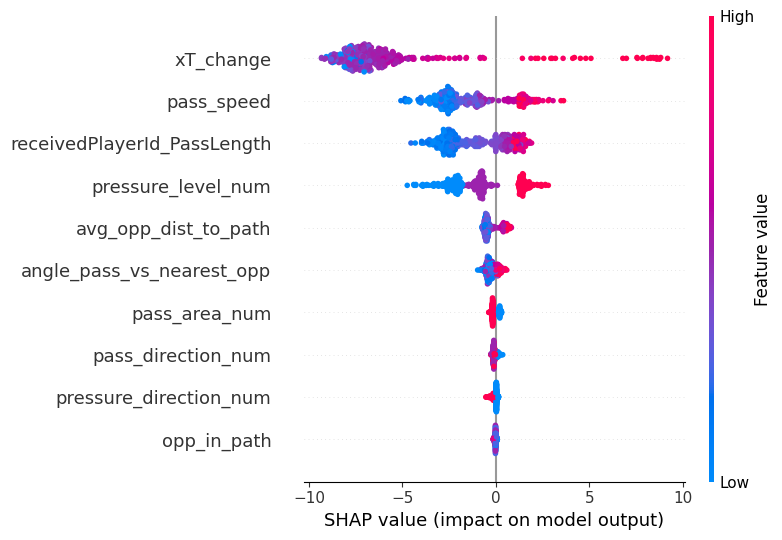

In [45]:
import sys
sys.path.append(r"C:\Users\Adolph\anaconda3\Lib\site-packages")

import shap
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)


In [74]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pandas as pd

# 读取数据
df = pd.read_csv("label_annotation_sample (1).csv")

# 特征列
features = [
    'pass_speed', 'receivedPlayerId_PassLength', 'pressure_level_num',
    'pressure_direction_num', 'pass_area_num', 'pass_direction_num', 'xT_change',
    'opp_in_path', 'avg_opp_dist_to_path', 'angle_pass_vs_nearest_opp'
]

# 删除缺失值
df = df.dropna(subset=features + ['human_label'])

# 目标变量
X = df[features]
y = df['human_label'].astype(int)

# 划分训练/测试集（用于普通训练和分类报告）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 训练模型
clf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
clf.fit(X_train, y_train)

# 预测并评估
y_pred = clf.predict(X_test)
print("单次划分结果：")
print(classification_report(y_test, y_pred))

# 5折交叉验证
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scores = cross_val_score(clf, X, y, cv=cv, scoring='f1')

# 输出交叉验证结果
print(" K-Fold 交叉验证 F1-score：")
for i, score in enumerate(f1_scores):
    print(f"Fold {i+1}: {score:.3f}")
print(f"平均 F1-score: {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")


单次划分结果：
              precision    recall  f1-score   support

           0       0.82      1.00      0.90         9
           1       1.00      0.71      0.83         7

    accuracy                           0.88        16
   macro avg       0.91      0.86      0.87        16
weighted avg       0.90      0.88      0.87        16

 K-Fold 交叉验证 F1-score：
Fold 1: 0.923
Fold 2: 0.875
Fold 3: 0.923
Fold 4: 0.923
Fold 5: 0.769
平均 F1-score: 0.883 ± 0.060


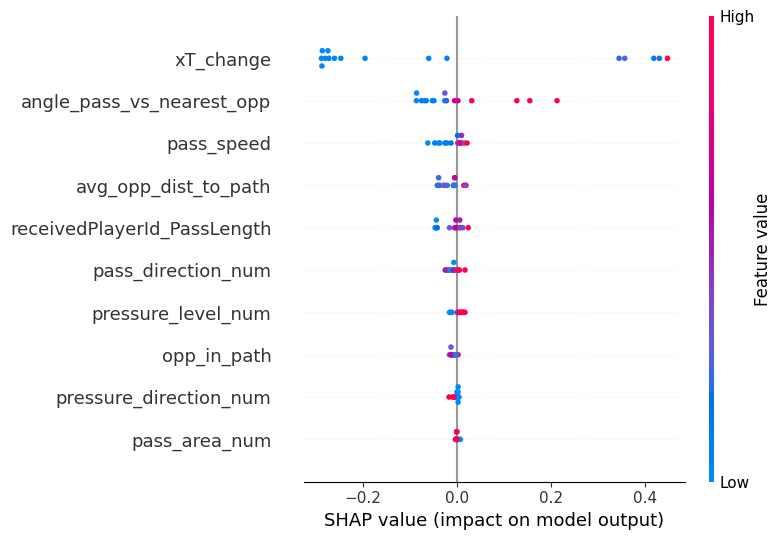

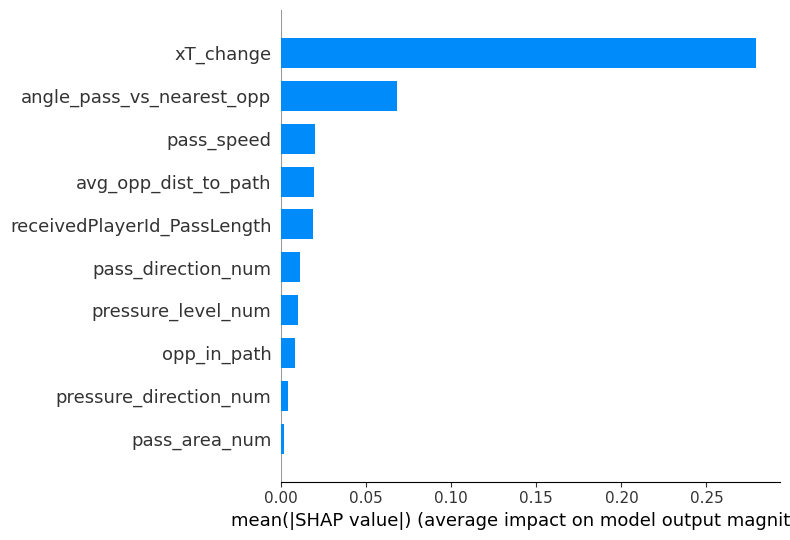

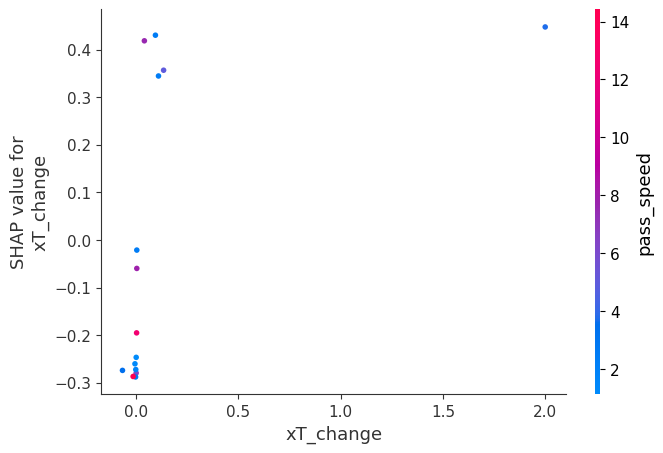

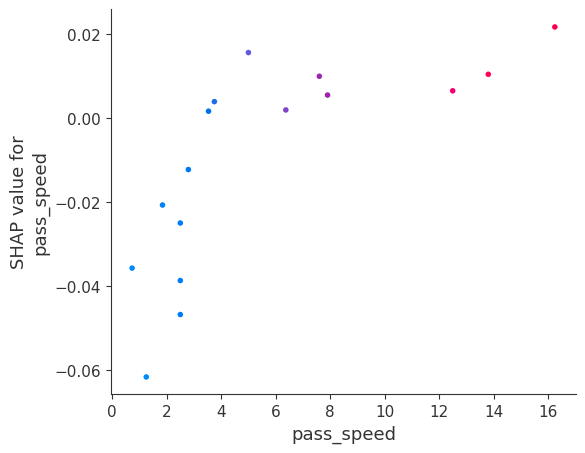

In [80]:
# 初始化 SHAP 解释器
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

# 处理 shap_values：根据维度确定使用方式
if isinstance(shap_values, list):
    shap_to_plot = shap_values[1]
elif shap_values.ndim == 3:
    shap_to_plot = shap_values[:, :, 1]
else:
    shap_to_plot = shap_values

# summary_plot 分布图（推荐用 jupyter notebook 运行）
shap.summary_plot(shap_to_plot, X_test)
shap.summary_plot(shap_to_plot, X_test, plot_type="bar")

# dependence plot：特征与模型影响关系
shap.dependence_plot("xT_change", shap_to_plot, X_test)
shap.dependence_plot("pass_speed", shap_to_plot, X_test)

# force_plot 单个样本解释（适合 HTML 或 notebook 显示）
i = 3
shap.initjs()
shap.plots.force(
    explainer.expected_value[1],
    shap_values[:, :, 1][i],
    X_test.iloc[i]
)


In [147]:
def extract_frame_players_and_roles(coordinates_df, row):
    timestamp = row['timestamp']
    passer_id = row['passedPlayerId']
    team_id = row['passedPlayerTeamId']

    frame = coordinates_df[coordinates_df['timestamp'] == timestamp]
    if frame.empty or pd.isna(timestamp):
        raise ValueError(f"No coordinate data found for timestamp {timestamp}")
    frame = frame.iloc[0]

    # Extract all players with valid IDs and positions
    player_rows = []
    for i in range(40):
        pid = frame.get(f'playerId{i}', -100)
        x = frame.get(f'posX{i}', -100)
        y = frame.get(f'posY{i}', -100)
        if pid == -100 or x == -100 or y == -100:
            continue
        player_rows.append({'player_index': i, 'player_id': pid, 'posX': x, 'posY': y})

    df_players = pd.DataFrame(player_rows)

    # Retrieve teammate and opponent IDs from pass record
    teammate_ids = [row.get(f'teamMatePlayerId{i}') for i in range(1, 11)]
    opponent_ids = [row.get(f'opponentPlayerId{i}') for i in range(1, 12)]

    # Assign roles
    df_players['is_passer'] = df_players['player_id'] == passer_id
    df_players['is_teammate'] = df_players['player_id'].isin(teammate_ids)
    df_players['is_opponent'] = df_players['player_id'].isin(opponent_ids)

    return row, df_players


In [148]:
def draw_frame_players(df_players, pass_row):
    # Set up pitch display
    plt.figure(figsize=(10, 6.5))
    plt.xlim(0, 105)
    plt.ylim(0, 68)
    plt.gca().set_facecolor('lightgreen')
    plt.title("Spatial Situation at the Time of the Pass", fontsize=14)

    receiver_id = pass_row.get('receivedPlayerId', None)

    # Draw passer
    passer = df_players[df_players['is_passer']]
    plt.scatter(passer['posX'], passer['posY'], color='blue', s=100, label='Passer')

    # Draw teammates (excluding receiver)
    teammates = df_players[df_players['is_teammate'] & (df_players['player_id'] != receiver_id)]
    plt.scatter(teammates['posX'], teammates['posY'], color='white', s=60, label='Teammates')

    # Draw receiver
    receiver = df_players[df_players['player_id'] == receiver_id]
    if not receiver.empty:
        plt.scatter(receiver['posX'], receiver['posY'], color='yellow', edgecolors='black', s=100, label='Receiver', zorder=5)

    # Draw opponents
    opponents = df_players[df_players['is_opponent']]
    plt.scatter(opponents['posX'], opponents['posY'], color='black', s=60, label='Opponents')

    # Annotate player IDs
    for _, row in df_players.iterrows():
        if pd.notna(row['player_id']):
            plt.text(row['posX'], row['posY'] + 1, str(int(row['player_id'])), fontsize=8, ha='center')

    # Draw pass arrow from passer to receiver
    try:
        passer_row = df_players[df_players['is_passer']].iloc[0]
        receiver_row = df_players[df_players['player_id'] == receiver_id].iloc[0]

        plt.arrow(
            passer_row['posX'], passer_row['posY'],
            receiver_row['posX'] - passer_row['posX'],
            receiver_row['posY'] - passer_row['posY'],
            width=0.3, head_width=2.2, length_includes_head=True, color='red', alpha=0.9
        )
    except:
        pass

    plt.xlabel("Field X")
    plt.ylabel("Field Y")
    plt.legend()
    plt.grid(True)
    plt.show()


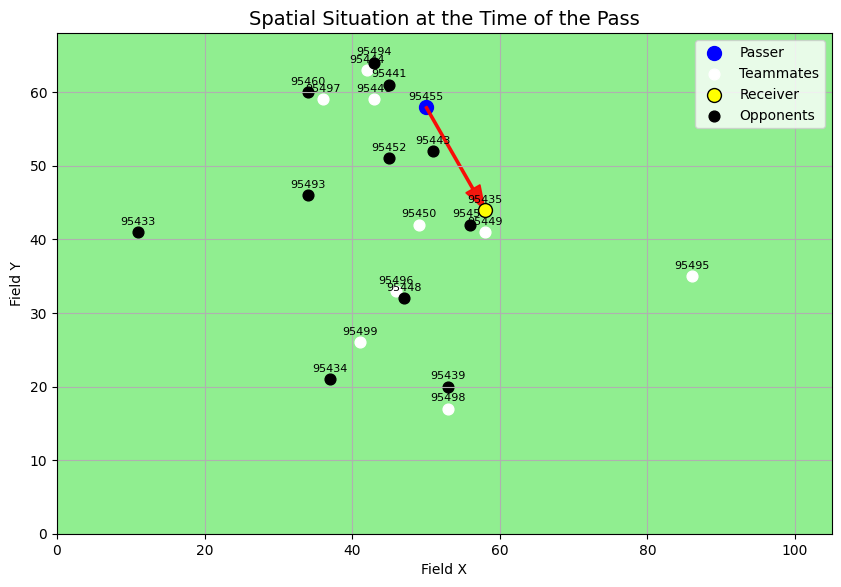

In [149]:
row = df_passes.iloc[500]  # 或 df_passes_cleaned.iloc[500]
pass_row, frame_players = extract_frame_players_and_roles(df_coordinates, row)
draw_frame_players(frame_players, pass_row)


KeyboardInterrupt: 

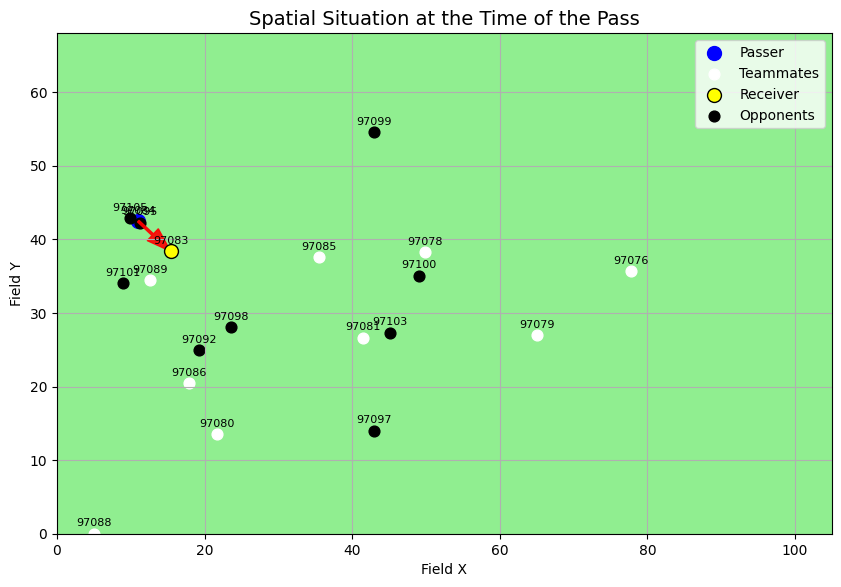

In [156]:
from collections import Counter
error_counter = Counter()



# 图像保存路径和数量
save_dir = r"C:\Users\Adolph\graduation thesis\image"
os.makedirs(save_dir, exist_ok=True)
num_samples = 500  # 总生成图像数量

# 确保有 window_score，并加 is_valuable
df = df.copy()
df['is_valuable'] = (df['window_score'] > 0.6).astype(int)

# 分离样本
df_positive = df[df['is_valuable'] == 1]
df_negative = df[df['is_valuable'] == 0].sample(n=max(0, num_samples - len(df_positive)), random_state=42)
df_selected = pd.concat([df_positive, df_negative]).sample(frac=1.0, random_state=42).reset_index(drop=True)

# 绘图函数（保持原样）
def draw_pass_frame_as_image(df_players, pass_row, save_path):
    plt.figure(figsize=(10, 6.5))
    plt.xlim(0, 105)
    plt.ylim(0, 68)
    plt.gca().set_facecolor('lightgreen')
    plt.title("Spatial Situation at the Time of the Pass", fontsize=14)

    receiver_id = pass_row.get('receivedPlayerId', None)
    passer = df_players[df_players['is_passer']]
    plt.scatter(passer['posX'], passer['posY'], color='blue', s=100, label='Passer')

    teammates = df_players[df_players['is_teammate'] & (df_players['player_id'] != receiver_id)]
    plt.scatter(teammates['posX'], teammates['posY'], color='white', s=60, label='Teammates')

    receiver = df_players[df_players['player_id'] == receiver_id]
    if not receiver.empty:
        plt.scatter(receiver['posX'], receiver['posY'], color='yellow', edgecolors='black', s=100, label='Receiver', zorder=5)

    opponents = df_players[df_players['is_opponent']]
    plt.scatter(opponents['posX'], opponents['posY'], color='black', s=60, label='Opponents')

    for _, row in df_players.iterrows():
        if pd.notna(row['player_id']):
            plt.text(row['posX'], row['posY'] + 1, str(int(row['player_id'])), fontsize=8, ha='center')

    try:
        passer_row = passer.iloc[0]
        receiver_row = receiver.iloc[0]
        plt.arrow(
            passer_row['posX'], passer_row['posY'],
            receiver_row['posX'] - passer_row['posX'],
            receiver_row['posY'] - passer_row['posY'],
            width=0.3, head_width=2.2, length_includes_head=True, color='red', alpha=0.9
        )
    except:
        pass

    plt.xlabel("Field X")
    plt.ylabel("Field Y")
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0.1)
    plt.close()

# 生成图像与标签
label_rows = []
count = 0

for idx, pass_row in df_selected.iterrows():
    ts = pass_row['timestamp']
    if pd.isna(ts):
        error_counter["timestamp NaN"] += 1
        continue
    try:
        pass_row_out, df_players = extract_frame_players_and_roles(df_coordinates, pass_row)

        img_name = f"pass_{idx:04d}.png"
        img_path = os.path.join(save_dir, img_name)
        draw_pass_frame_as_image(df_players, pass_row_out, img_path)

        label_rows.append({
            'filename': img_name,
            'is_valuable': int(pass_row['is_valuable'])
        })
        count += 1

    except Exception as e:
        error_counter[str(e)] += 1
        continue

# 保存标签文件
df_labels = pd.DataFrame(label_rows)
csv_path = os.path.join(save_dir, "pass_labels_valuable.csv")
df_labels.to_csv(csv_path, index=False)

print(f"Images generated: {count}")
print(f"Label CSV saved to: {csv_path}")
print(df_labels['is_valuable'].value_counts())
print(df_labels.head())
print("Error Summary:")
for err, count in error_counter.most_common():
    print(f"{err}: {count}")

In [161]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split

# 参数设置
image_dir = r"C:\Users\Adolph\graduation thesis\image"
label_path = os.path.join(image_dir, "pass_labels_valuable.csv")
df = pd.read_csv(label_path)

# 数据清理
df = df.dropna(subset=['is_valuable'])
df['is_valuable'] = df['is_valuable'].astype(int)

# 划分训练和验证集
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['is_valuable'])

# CNN 图像数据加载器
class ImageDataset(Sequence):
    def __init__(self, df, batch_size=32, image_size=(224, 224), shuffle=True):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.image_size = image_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index*self.batch_size:(index+1)*self.batch_size]
        batch_df = self.df.iloc[batch_indices]

        images, labels = [], []
        for _, row in batch_df.iterrows():
            img_path = os.path.join(image_dir, row['filename'])
            img = load_img(img_path, target_size=self.image_size)
            img_array = img_to_array(img) / 255.0
            images.append(img_array)
            labels.append(row['is_valuable'])

        return np.array(images), np.array(labels, dtype=np.float32)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# 生成器
train_gen = ImageDataset(train_df, batch_size=32)
val_gen = ImageDataset(val_df, batch_size=32, shuffle=False)

# 模型构建
def build_binary_classifier(input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, output)

# 编译模型
model = build_binary_classifier()
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=losses.BinaryCrossentropy(),
    metrics=[
        metrics.BinaryAccuracy(),
        metrics.Precision(),
        metrics.Recall(),
        metrics.AUC()
    ]
)

# 训练模型
model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight={0: 1.0, 1: 2.0}, 
    verbose=1
)

# 保存模型
model.save("cnn_model_is_valuable.h5")


C:\Users\Adolph\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 874ms/step - auc_7: 0.4887 - binary_accuracy: 0.4753 - loss: 0.9449 - precision_7: 0.3589 - recall_7: 0.5760 - val_auc_7: 0.5000 - val_binary_accuracy: 0.3500 - val_loss: 0.7032 - val_precision_7: 0.3500 - val_recall_7: 1.0000
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 820ms/step - auc_7: 0.5240 - binary_accuracy: 0.3646 - loss: 0.9371 - precision_7: 0.3538 - recall_7: 0.9577 - val_auc_7: 0.5000 - val_binary_accuracy: 0.3500 - val_loss: 0.7069 - val_precision_7: 0.3500 - val_recall_7: 1.0000
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 803ms/step - auc_7: 0.4810 - binary_accuracy: 0.3833 - loss: 0.9514 - precision_7: 0.3781 - recall_7: 0.9790 - val_auc_7: 0.5000 - val_binary_accuracy: 0.3500 - val_loss: 0.7061 - val_precision_7: 0.3500 - val_recall_7: 1.0000
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 792ms/step - auc_7: 0.4633 - binary_accuracy: 0.3500 - loss: 0.9291 - precision_7: 0.3324 - recall_7: 0.9153 - val_auc_7: 0.5000 - val_binary_accuracy:

In [128]:
df_passes_cleaned['timestamp'].isna().sum()


0

In [129]:
df_selected['timestamp'].isna().sum()


0

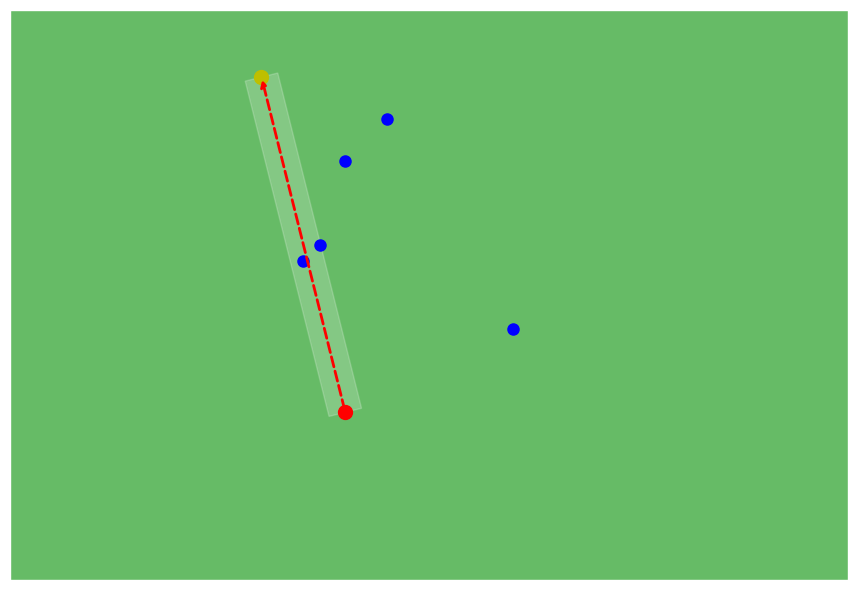

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 创建图像
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 100)
ax.set_ylim(0, 68)
ax.set_aspect('equal')
ax.axis('off')

# 球场背景（浅绿色）
field = patches.Rectangle((0, 0), 100, 68, edgecolor='white', facecolor='#66bb66')  # 浅绿
ax.add_patch(field)

# 传球者和接球者坐标
passer = (40, 20)
receiver = (30, 60)
ax.plot(*passer, 'ro', markersize=10)       # 传球者：红色
ax.plot(*receiver, 'yo', markersize=10)     # 接球者：黄色

# 添加传球路径箭头
ax.annotate('', xy=receiver, xytext=passer,
            arrowprops=dict(arrowstyle='->', color='red', lw=2, linestyle='--'))

# 计算矩形路径区域（两侧扩展 2m 的“通道”）
dx = receiver[0] - passer[0]
dy = receiver[1] - passer[1]
length = (dx**2 + dy**2) ** 0.5
unit_dx = dx / length
unit_dy = dy / length
# 垂直方向单位向量（逆时针90°旋转）
perp_dx = -unit_dy
perp_dy = unit_dx
half_width = 2  # 每侧2米

# 四个点定义矩形
p1 = (passer[0] + perp_dx * half_width, passer[1] + perp_dy * half_width)
p2 = (passer[0] - perp_dx * half_width, passer[1] - perp_dy * half_width)
p3 = (receiver[0] - perp_dx * half_width, receiver[1] - perp_dy * half_width)
p4 = (receiver[0] + perp_dx * half_width, receiver[1] + perp_dy * half_width)

# 画路径区域多边形
polygon = patches.Polygon([p1, p2, p3, p4], closed=True, color='white', alpha=0.2)
ax.add_patch(polygon)

# 添加对手球员（部分在路径区内，部分在外）
opponents = [(35, 38), (37, 40), (45, 55), (60, 30), (40, 50)]
for opp in opponents:
    ax.plot(*opp, 'bo', markersize=8)  # 蓝色代表对手

# 保存图像
plt.tight_layout()
plt.savefig("opponent_density_diagram_updated.png", dpi=300)
plt.show()


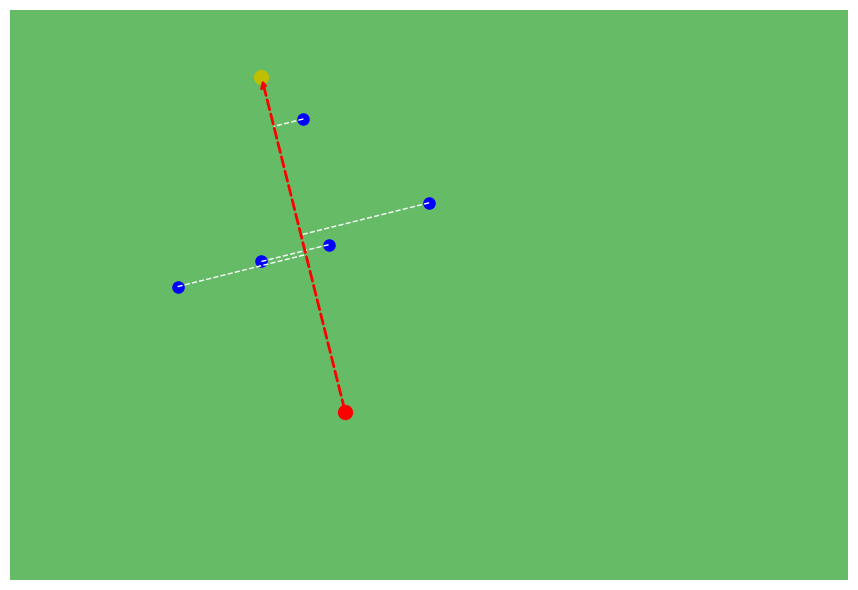

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# 创建图像
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 100)
ax.set_ylim(0, 68)
ax.set_aspect('equal')
ax.axis('off')

# 背景浅绿
ax.add_patch(patches.Rectangle((0, 0), 100, 68, facecolor='#66bb66'))

# 传球者与接球者
passer = (40, 20)
receiver = (30, 60)
ax.plot(*passer, 'ro', markersize=10)
ax.plot(*receiver, 'yo', markersize=10)

# 传球路径箭头
ax.annotate('', xy=receiver, xytext=passer,
            arrowprops=dict(arrowstyle='->', color='red', lw=2, linestyle='--'))

# 对手位置
opponents = [(38, 40), (20, 35), (50, 45), (30, 38), (35, 55)]
for opp in opponents:
    ax.plot(*opp, 'bo', markersize=8)

# 计算路径向量 & 垂直距离
def perp_distance(p, a, b):
    # 点 p 到直线 ab 的垂直距离
    num = abs((b[0]-a[0])*(a[1]-p[1]) - (a[0]-p[0])*(b[1]-a[1]))
    den = ((b[0]-a[0])**2 + (b[1]-a[1])**2)**0.5
    return num / den

# 画垂线
for opp in opponents:
    # 投影点（线段上最近点）
    ap = np.array([opp[0] - passer[0], opp[1] - passer[1]])
    ab = np.array([receiver[0] - passer[0], receiver[1] - passer[1]])
    t = np.dot(ap, ab) / np.dot(ab, ab)
    proj = passer[0] + t * ab[0], passer[1] + t * ab[1]
    ax.plot([opp[0], proj[0]], [opp[1], proj[1]], 'w--', linewidth=1)



plt.tight_layout()
plt.savefig("avg_opp_dist_to_path.png", dpi=300)
plt.show()


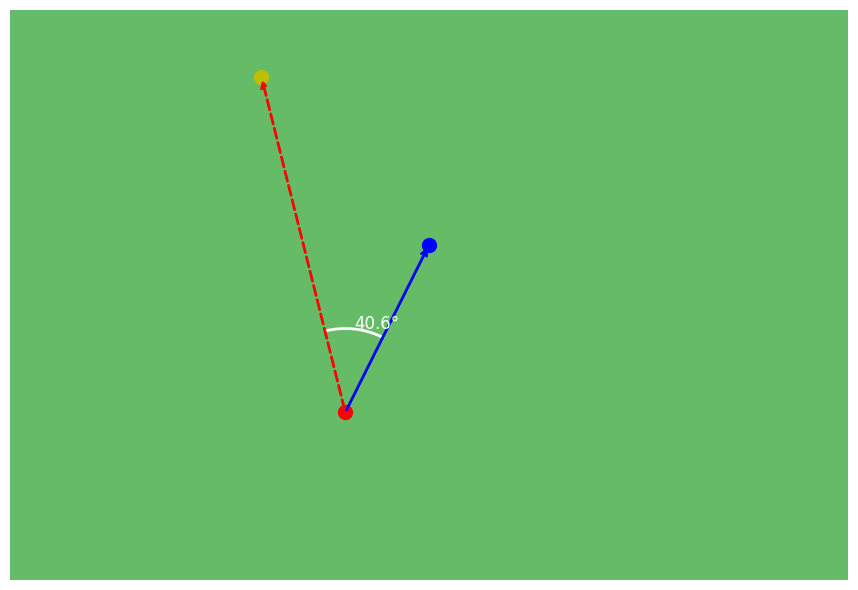

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# 创建图像
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 100)
ax.set_ylim(0, 68)
ax.set_aspect('equal')
ax.axis('off')

# 浅绿色背景
ax.add_patch(patches.Rectangle((0, 0), 100, 68, facecolor='#66bb66'))

# 坐标定义
passer = (40, 20)
receiver = (30, 60)
opponent = (50, 40)

# 绘制球员
ax.plot(*passer, 'ro', markersize=10)
ax.plot(*receiver, 'yo', markersize=10)
ax.plot(*opponent, 'bo', markersize=10)

# 绘制箭头路径
ax.annotate('', xy=receiver, xytext=passer,
            arrowprops=dict(arrowstyle='->', color='red', lw=2, linestyle='--'))
ax.annotate('', xy=opponent, xytext=passer,
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))

# =========================
# 修正：从对手方向扫到传球方向
# =========================

# 向量定义（顺序换了！）
v1 = np.array([opponent[0] - passer[0], opponent[1] - passer[1]])  # blue → center
v2 = np.array([receiver[0] - passer[0], receiver[1] - passer[1]])  # yellow → center

# 转为角度
angle1 = np.degrees(np.arctan2(v1[1], v1[0]))
angle2 = np.degrees(np.arctan2(v2[1], v2[0]))

# 夹角差
angle_diff = (angle2 - angle1 + 360) % 360
if angle_diff > 180:
    angle_diff -= 360

start_angle = angle1
end_angle = angle1 + angle_diff


# 绘制弧线
arc_radius = 10
arc = patches.Arc(passer, arc_radius*2, arc_radius*2,
                  angle=0, theta1=start_angle, theta2=end_angle,
                  color='white', lw=2)
ax.add_patch(arc)

# 角度文字居中位置
mid_angle = (start_angle + end_angle) / 2
mid_rad = np.radians(mid_angle)
text_x = passer[0] + arc_radius * np.cos(mid_rad)
text_y = passer[1] + arc_radius * np.sin(mid_rad)
ax.text(text_x, text_y, f"{abs(angle_diff):.1f}°", color='white', fontsize=12)



plt.tight_layout()
plt.savefig("angle_pass_vs_nearest_opp_corrected.png", dpi=300)
plt.show()
